# Manuscript Tables, Figures, and Results Narrative for ECG-Derived Hemodynamic Instability Candidate Features

## Notebook purpose

This notebook prepares manuscript-ready outputs from the completed ECG-derived hemodynamic instability feature-discovery pipeline. The goal is to generate clear tables, figures, and concise Results text that can support a manuscript submission, while preserving the exploratory nature of the analysis.

This notebook does **not** repeat the full statistical discovery pipeline. The feature extraction, patient-level aggregation, paired comparisons, redundancy review, robustness checks, and final feature categorization have already been completed and validated in the earlier pipeline stages. Instead, this notebook uses the final validated workbook and selected pipeline outputs as source material for manuscript preparation.

## Study context

This work examines ECG-derived features in a 20-patient intensive care cohort with cardiogenic shock and/or hemodynamic instability. The analysis compares ECG feature behavior between two clinical states:

- **PreHI**: ECG segments recorded before hemodynamic instability
- **HI**: ECG segments recorded during hemodynamic instability

The primary analysis unit is the **patient**, not the individual ECG segment. Segment-level ECG features were summarized within each patient and condition, and the main comparison was performed using patient-level paired PreHI versus HI summaries. This design helps reduce the risk of overinterpreting the large number of ECG segments as independent observations.

## Scientific framing

This is an exploratory, hypothesis-generating ECG biomarker study. The final feature categories should be interpreted as evidence-prioritized candidate features, not as validated clinical biomarkers. The outputs from this notebook should therefore use cautious language such as:

- candidate ECG feature
- exploratory patient-level evidence
- directional consistency
- supportive robustness analysis
- rhythm-sensitive feature
- descriptive clinical context
- requires external validation

The notebook should avoid language implying diagnostic validation, prediction accuracy, causal inference, or clinical deployment.

A central interpretation from the validated pipeline is that **no feature survived global or family-level FDR correction**. Therefore, the final features are retained as exploratory candidates based on combined evidence from raw patient-level support, directional consistency, redundancy review, robustness analyses, and clinical interpretability.

## Main data source

The primary input for this notebook is the final validated workbook:

```text
outputs/final_workbook/HI_ECG_candidate_feature_analysis_workbook.xlsx
```

This workbook contains the validated outputs from the completed pipeline and is treated as the source of truth for manuscript table and figure generation.

Expected workbook sheets include:

```text
README
Workbook_Index
Final_Scorecard
Final_Categories
Manuscript_Summary
Prelim_Shortlist
Primary_Stats
Redundancy_Clusters
Cluster_Reps
HRV_Subgroup
LMM_Supportive
Sensitivity_Robustness
LOO_Summary
Feature_Agreement
Patient_Disagreement
Clinical_Disagreement
QC_Counts
Cohort_Description
```

## Final exploratory feature categories

The validated final categories from the pipeline are:

### Primary exploratory candidates

- `kurtosis`
- `QRS_mean`
- `entropyProfiled_maximum_sampleEntropy`

### Secondary exploratory candidates

- `fuzzyEntropy`
- `fd_median`
- `entropyProfiled_standardDeviation_sampleEntropy`

### Secondary rhythm-sensitive candidates

- `HRV_pNN50`
- `HRV_MeanNN`

### Exploratory or downgraded feature

- `fd_minimum`

These categories summarize exploratory evidence strength and interpretation. They should not be interpreted as validation tiers.

## Planned notebook outputs

This notebook will generate:

1. **Manuscript-ready tables** summarizing cohort context, primary paired analysis, final candidate scorecard, robustness analyses, and patient-level agreement/disagreement.
2. **Manuscript-ready figures** summarizing the workflow, candidate evidence profile, patient-level agreement patterns, direction consistency, and selected clinical disagreement context.
3. **Concise Results narrative** written in cautious manuscript style and based only on the validated pipeline outputs.
4. **Exported files** saved into organized output folders for direct manuscript use.

Suggested output folders:

```text
outputs/manuscript_tables/
outputs/figures/
outputs/manuscript_text/
```

## Reproducibility and interpretation safeguards

This notebook should:

- load all manuscript outputs directly from the final validated workbook;
- check that required sheets, columns, and final candidate features are present;
- avoid rerunning or modifying the original discovery analyses;
- clearly label all findings as exploratory;
- distinguish patient-level primary evidence from segment-level supportive analyses;
- treat clinical disagreement patterns as descriptive rather than formal association tests;
- explicitly state that external validation is required before clinical interpretation or deployment.


In [2]:
# ============================================================
# Section 1 — Imports and paths
# Manuscript tables, figures, and Results narrative notebook
# ============================================================

# -----------------------------
# 1.1 Core imports
# -----------------------------

from pathlib import Path
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional, mainly useful for heatmaps.
# The notebook will still work if seaborn is unavailable.
try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ImportError:
    SEABORN_AVAILABLE = False
    print("Warning: seaborn is not installed. Heatmaps will use matplotlib fallback options.")

# Excel support
try:
    import openpyxl
except ImportError as exc:
    raise ImportError(
        "openpyxl is required to read and write Excel workbooks. "
        "Please install it before running this notebook."
    ) from exc


# -----------------------------
# 1.2 Notebook display settings
# -----------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

warnings.filterwarnings("default")


# -----------------------------
# 1.3 Project paths
# -----------------------------

# Assumption:
# Run this notebook from a notebook/scripts folder one level below the project root.
# Therefore, the project root is one directory above the current working directory.
PROJECT_ROOT = Path.cwd().parent

# Primary validated workbook generated by the completed ECG HI pipeline
WORKBOOK_PATH = PROJECT_ROOT / "outputs" / "final_workbook" / "HI_ECG_candidate_feature_analysis_workbook.xlsx"

# Output folders for manuscript-stage products
TABLE_DIR = PROJECT_ROOT / "outputs" / "manuscript_tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TEXT_DIR = PROJECT_ROOT / "outputs" / "manuscript_text"

# Create output folders if they do not already exist
for output_dir in [TABLE_DIR, FIGURE_DIR, TEXT_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)


# -----------------------------
# 1.4 Figure export settings
# -----------------------------

FIG_DPI = 300

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "figure.figsize": (8, 5),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# -----------------------------
# 1.5 Final feature definitions
# -----------------------------

FINAL_FEATURES = [
    "kurtosis",
    "QRS_mean",
    "entropyProfiled_maximum_sampleEntropy",
    "fuzzyEntropy",
    "fd_median",
    "entropyProfiled_standardDeviation_sampleEntropy",
    "HRV_pNN50",
    "HRV_MeanNN",
    "fd_minimum",
]

FINAL_FEATURE_CATEGORIES = {
    "primary_exploratory_candidate": [
        "kurtosis",
        "QRS_mean",
        "entropyProfiled_maximum_sampleEntropy",
    ],
    "secondary_exploratory_candidate": [
        "fuzzyEntropy",
        "fd_median",
        "entropyProfiled_standardDeviation_sampleEntropy",
    ],
    "secondary_rhythm_sensitive_candidate": [
        "HRV_pNN50",
        "HRV_MeanNN",
    ],
    "exploratory_or_downgraded": [
        "fd_minimum",
    ],
}

NON_INFORMATIVE_FEATURES_REMOVED = [
    "entropyProfiled_minimum_sampleEntropy",
    "mean",
    "positiveToNegativePeakRatio",
    "shannonEntropy",
]


# -----------------------------
# 1.6 Expected workbook sheets
# -----------------------------

EXPECTED_SHEETS = [
    "README",
    "Workbook_Index",
    "Final_Scorecard",
    "Final_Categories",
    "Manuscript_Summary",
    "Prelim_Shortlist",
    "Primary_Stats",
    "Redundancy_Clusters",
    "Cluster_Reps",
    "HRV_Subgroup",
    "LMM_Supportive",
    "Sensitivity_Robustness",
    "LOO_Summary",
    "Feature_Agreement",
    "Patient_Disagreement",
    "Clinical_Disagreement",
    "QC_Counts",
    "Cohort_Description",
]

CRITICAL_SHEETS = [
    "Final_Scorecard",
    "Final_Categories",
    "Primary_Stats",
    "Manuscript_Summary",
    "Feature_Agreement",
    "Patient_Disagreement",
    "Clinical_Disagreement",
    "Cohort_Description",
]


# -----------------------------
# 1.7 Helper functions
# -----------------------------

def print_section_header(title: str) -> None:
    """
    Print a readable section header in notebook output.
    """
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def check_file_exists(path: Path, label: str = "File") -> None:
    """
    Raise a clear error if an expected file does not exist.
    """
    if not path.exists():
        raise FileNotFoundError(
            f"{label} not found:\n{path}\n\n"
            "Check that the notebook is being run from the project root directory "
            "or update PROJECT_ROOT / WORKBOOK_PATH in Section 1."
        )


def save_table(df: pd.DataFrame, base_filename: str, index: bool = False) -> None:
    """
    Save a manuscript table as both CSV and Excel.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Table to save.
    base_filename : str
        Filename without extension.
    index : bool
        Whether to write the DataFrame index.
    """
    csv_path = TABLE_DIR / f"{base_filename}.csv"
    xlsx_path = TABLE_DIR / f"{base_filename}.xlsx"
    
    df.to_csv(csv_path, index=index)
    df.to_excel(xlsx_path, index=index)
    
    print(f"Saved CSV:  {csv_path}")
    print(f"Saved XLSX: {xlsx_path}")


def save_current_figure(base_filename: str) -> None:
    """
    Save the current matplotlib figure as PNG, SVG, and PDF.
    
    Parameters
    ----------
    base_filename : str
        Filename without extension.
    """
    png_path = FIGURE_DIR / f"{base_filename}.png"
    svg_path = FIGURE_DIR / f"{base_filename}.svg"
    pdf_path = FIGURE_DIR / f"{base_filename}.pdf"
    
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(svg_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    print(f"Saved PDF: {pdf_path}")


def normalize_feature_name(value) -> str:
    """
    Convert a feature name-like value to a clean string.
    """
    if pd.isna(value):
        return ""
    return str(value).strip()


# -----------------------------
# 1.8 Initial verification output
# -----------------------------

print_section_header("Section 1 setup complete")

print(f"Project root:   {PROJECT_ROOT}")
print(f"Workbook path:  {WORKBOOK_PATH}")
print(f"Table output:   {TABLE_DIR}")
print(f"Figure output:  {FIGURE_DIR}")
print(f"Text output:    {TEXT_DIR}")

print("\nFinal feature count:", len(FINAL_FEATURES))
print("Final feature categories:", list(FINAL_FEATURE_CATEGORIES.keys()))
print("Seaborn available:", SEABORN_AVAILABLE)

# Check workbook presence now, before proceeding to Section 2
check_file_exists(WORKBOOK_PATH, label="Final validated workbook")

print("\nWorkbook found. Ready for Section 2 — Load workbook sheets.")


Section 1 setup complete
Project root:   /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI
Workbook path:  /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/final_workbook/HI_ECG_candidate_feature_analysis_workbook.xlsx
Table output:   /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables
Figure output:  /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/figures
Text output:    /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_text

Final feature count: 9
Final feature categories: ['primary_exploratory_candidate', 'secondary_exploratory_candidate', 'secondary_rhythm_sensitive_candidate', 'exploratory_or_downgraded']
Seaborn available: 

## Section 2 — Load Workbook Sheets

In this section, we load the validated final workbook generated by the completed ECG-derived hemodynamic instability feature-discovery pipeline.

The workbook is treated as the primary source for this manuscript-stage notebook. This means that the notebook will not repeat feature extraction, patient-level statistical testing, redundancy filtering, mixed-effects modelling, sensitivity analysis, or leave-one-patient-out analysis. Instead, it will read the already validated outputs and organize them into manuscript-ready tables, figures, and Results text.

The expected workbook is:

`outputs/final_workbook/HI_ECG_candidate_feature_analysis_workbook.xlsx`

This workbook contains multiple sheets representing different parts of the completed pipeline, including the final candidate scorecard, primary paired statistics, feature categories, robustness analyses, patient-level agreement/disagreement summaries, clinical disagreement context, quality-control counts, and cohort description.

The goal of this section is to:

1. Confirm that the workbook exists.
2. Read all available sheets into Python.
3. Store the sheets in a dictionary of pandas DataFrames.
4. Display the sheet names and dimensions.
5. Identify any expected sheets that are missing before proceeding.

This step is important because all downstream manuscript tables and figures depend on these workbook sheets being loaded correctly. Any missing or unexpectedly structured sheet will be flagged early so that errors are not silently carried into the manuscript outputs.

In [3]:
# ============================================================
# Section 2 — Load workbook sheets
# ============================================================

print_section_header("Section 2 — Load workbook sheets")

# -----------------------------
# 2.1 Confirm workbook exists
# -----------------------------

check_file_exists(WORKBOOK_PATH, label="Final validated workbook")

print(f"Loading workbook from:\n{WORKBOOK_PATH}")


# -----------------------------
# 2.2 Inspect available sheets
# -----------------------------

excel_file = pd.ExcelFile(WORKBOOK_PATH)
available_sheets = excel_file.sheet_names

print("\nAvailable sheets in workbook:")
for sheet_name in available_sheets:
    print(f"  - {sheet_name}")


# -----------------------------
# 2.3 Compare expected vs available sheets
# -----------------------------

missing_expected_sheets = [s for s in EXPECTED_SHEETS if s not in available_sheets]
extra_sheets = [s for s in available_sheets if s not in EXPECTED_SHEETS]
missing_critical_sheets = [s for s in CRITICAL_SHEETS if s not in available_sheets]

if missing_expected_sheets:
    print("\nWarning: The following expected sheets are missing:")
    for sheet_name in missing_expected_sheets:
        print(f"  - {sheet_name}")
else:
    print("\nAll expected sheets are present.")

if extra_sheets:
    print("\nNote: The workbook contains additional sheets not listed in EXPECTED_SHEETS:")
    for sheet_name in extra_sheets:
        print(f"  - {sheet_name}")

if missing_critical_sheets:
    raise ValueError(
        "Critical workbook sheets are missing. Cannot safely continue.\n"
        f"Missing critical sheets: {missing_critical_sheets}"
    )

print("\nAll critical sheets are present.")


# -----------------------------
# 2.4 Load sheets into dictionary
# -----------------------------

sheets = {}

for sheet_name in available_sheets:
    try:
        sheets[sheet_name] = pd.read_excel(WORKBOOK_PATH, sheet_name=sheet_name)
    except Exception as exc:
        raise RuntimeError(
            f"Failed to load sheet '{sheet_name}' from workbook."
        ) from exc

print(f"\nLoaded {len(sheets)} sheets into the `sheets` dictionary.")


# -----------------------------
# 2.5 Create sheet summary table
# -----------------------------

sheet_summary = pd.DataFrame(
    [
        {
            "sheet_name": sheet_name,
            "n_rows": df.shape[0],
            "n_columns": df.shape[1],
            "is_expected": sheet_name in EXPECTED_SHEETS,
            "is_critical": sheet_name in CRITICAL_SHEETS,
        }
        for sheet_name, df in sheets.items()
    ]
).sort_values(["is_critical", "is_expected", "sheet_name"], ascending=[False, False, True])

display(sheet_summary)


# -----------------------------
# 2.6 Preview critical sheets
# -----------------------------

print("\nPreview of critical sheet dimensions:")

for sheet_name in CRITICAL_SHEETS:
    df = sheets[sheet_name]
    print(f"{sheet_name}: {df.shape[0]} rows × {df.shape[1]} columns")


# -----------------------------
# 2.7 Store commonly used sheets as variables
# -----------------------------

final_scorecard = sheets["Final_Scorecard"]
final_categories = sheets["Final_Categories"]
primary_stats = sheets["Primary_Stats"]
manuscript_summary = sheets["Manuscript_Summary"]
feature_agreement = sheets["Feature_Agreement"]
patient_disagreement = sheets["Patient_Disagreement"]
clinical_disagreement = sheets["Clinical_Disagreement"]
cohort_description = sheets["Cohort_Description"]

# Optional sheets used later for robustness tables and figures
hrv_subgroup = sheets.get("HRV_Subgroup")
lmm_supportive = sheets.get("LMM_Supportive")
sensitivity_robustness = sheets.get("Sensitivity_Robustness")
loo_summary = sheets.get("LOO_Summary")
qc_counts = sheets.get("QC_Counts")
redundancy_clusters = sheets.get("Redundancy_Clusters")
cluster_reps = sheets.get("Cluster_Reps")


# -----------------------------
# 2.8 Final status message
# -----------------------------

print("\nSection 2 complete.")
print("Workbook sheets are loaded and ready for Section 3 — Data checks.")


Section 2 — Load workbook sheets
Loading workbook from:
/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/final_workbook/HI_ECG_candidate_feature_analysis_workbook.xlsx

Available sheets in workbook:
  - README
  - Workbook_Index
  - Final_Scorecard
  - Final_Categories
  - Manuscript_Summary
  - Prelim_Shortlist
  - Primary_Stats
  - Redundancy_Clusters
  - Cluster_Reps
  - HRV_Subgroup
  - LMM_Supportive
  - Sensitivity_Robustness
  - LOO_Summary
  - Feature_Agreement
  - Patient_Disagreement
  - Clinical_Disagreement
  - QC_Counts
  - Cohort_Description

All expected sheets are present.

All critical sheets are present.

Loaded 18 sheets into the `sheets` dictionary.


,sheet_name,n_rows,n_columns,is_expected,is_critical
15,Clinical_Disagreement,144,11,True,True
17,Cohort_Description,20,2,True,True
13,Feature_Agreement,9,17,True,True
3,Final_Categories,4,3,True,True
2,Final_Scorecard,9,104,True,True
4,Manuscript_Summary,9,17,True,True
14,Patient_Disagreement,20,11,True,True
6,Primary_Stats,52,25,True,True
8,Cluster_Reps,39,15,True,False
9,HRV_Subgroup,4,26,True,False



Preview of critical sheet dimensions:
Final_Scorecard: 9 rows × 104 columns
Final_Categories: 4 rows × 3 columns
Primary_Stats: 52 rows × 25 columns
Manuscript_Summary: 9 rows × 17 columns
Feature_Agreement: 9 rows × 17 columns
Patient_Disagreement: 20 rows × 11 columns
Clinical_Disagreement: 144 rows × 11 columns
Cohort_Description: 20 rows × 2 columns

Section 2 complete.
Workbook sheets are loaded and ready for Section 3 — Data checks.


## Section 3 — Data Checks

In this section, we perform basic verification checks on the workbook sheets loaded in Section 2.

The purpose of this section is not to repeat the statistical pipeline. Instead, the goal is to confirm that the manuscript notebook has access to the expected final outputs and that the key sheets contain enough information to generate tables, figures, and Results text safely.

These checks help prevent common problems such as:

- missing workbook sheets,
- missing final candidate features,
- unexpected column names,
- empty tables,
- incomplete robustness outputs,
- or accidental use of the wrong workbook.

The notebook will specifically check whether the final exploratory candidate features are present in the loaded workbook and whether the expected evidence categories are represented.

The final feature set being carried forward into the manuscript-stage outputs is:

```text
Primary exploratory candidates:
- kurtosis
- QRS_mean
- entropyProfiled_maximum_sampleEntropy

Secondary exploratory candidates:
- fuzzyEntropy
- fd_median
- entropyProfiled_standardDeviation_sampleEntropy

Secondary rhythm-sensitive candidates:
- HRV_pNN50
- HRV_MeanNN

Exploratory or downgraded feature:
- fd_minimum

In [4]:
# ============================================================
# Section 3 — Data checks
# ============================================================

print_section_header("Section 3 — Data checks")


# -----------------------------
# 3.1 Helper functions for checks
# -----------------------------

def find_feature_column(df: pd.DataFrame):
    """
    Try to identify the column that contains feature names.
    
    This is intentionally flexible because different sheets may use
    slightly different labels, such as 'feature', 'Feature', or 'feature_name'.
    """
    possible_names = [
        "feature",
        "Feature",
        "feature_name",
        "Feature_Name",
        "feature_id",
        "Feature_ID",
        "variable",
        "Variable",
    ]
    
    for col in possible_names:
        if col in df.columns:
            return col
    
    # Fallback: search for columns that contain the word 'feature'
    for col in df.columns:
        if "feature" in str(col).lower():
            return col
    
    return None


def find_category_column(df: pd.DataFrame):
    """
    Try to identify the column that contains final feature categories.
    """
    possible_names = [
        "category",
        "Category",
        "final_category",
        "Final_Category",
        "feature_category",
        "Feature_Category",
        "evidence_category",
        "Evidence_Category",
    ]
    
    for col in possible_names:
        if col in df.columns:
            return col
    
    # Fallback: search for likely category columns
    for col in df.columns:
        col_lower = str(col).lower()
        if "category" in col_lower or "tier" in col_lower or "class" in col_lower:
            return col
    
    return None


def collect_features_from_sheets(sheets_dict: dict) -> dict:
    """
    Collect feature names found in each sheet where a feature-like column exists.
    """
    feature_locations = {}
    
    for sheet_name, df in sheets_dict.items():
        feature_col = find_feature_column(df)
        
        if feature_col is not None:
            values = (
                df[feature_col]
                .dropna()
                .map(normalize_feature_name)
                .replace("", np.nan)
                .dropna()
                .unique()
                .tolist()
            )
            feature_locations[sheet_name] = {
                "feature_column": feature_col,
                "features": values,
                "n_features": len(values),
            }
    
    return feature_locations


def check_dataframe_not_empty(df: pd.DataFrame, sheet_name: str) -> None:
    """
    Raise an error if a critical sheet is empty.
    """
    if df.empty:
        raise ValueError(f"Critical sheet '{sheet_name}' is empty.")


# -----------------------------
# 3.2 Confirm critical sheets are loaded and non-empty
# -----------------------------

print("\nChecking critical sheets...")

for sheet_name in CRITICAL_SHEETS:
    if sheet_name not in sheets:
        raise ValueError(f"Critical sheet missing from loaded sheets: {sheet_name}")
    
    check_dataframe_not_empty(sheets[sheet_name], sheet_name)
    print(f"  OK: {sheet_name} — {sheets[sheet_name].shape[0]} rows × {sheets[sheet_name].shape[1]} columns")

print("\nAll critical sheets are present and non-empty.")


# -----------------------------
# 3.3 Print columns in critical sheets
# -----------------------------

print("\nColumns available in critical sheets:")

for sheet_name in CRITICAL_SHEETS:
    print(f"\n{sheet_name}:")
    for col in sheets[sheet_name].columns:
        print(f"  - {col}")


# -----------------------------
# 3.4 Identify feature-name columns across workbook
# -----------------------------

print("\nIdentifying feature-name columns across workbook...")

feature_locations = collect_features_from_sheets(sheets)

feature_location_summary = pd.DataFrame(
    [
        {
            "sheet_name": sheet_name,
            "feature_column": info["feature_column"],
            "n_unique_features": info["n_features"],
        }
        for sheet_name, info in feature_locations.items()
    ]
).sort_values("sheet_name")

display(feature_location_summary)


# -----------------------------
# 3.5 Check final candidate feature presence
# -----------------------------

print("\nChecking presence of final candidate features...")

all_features_found = set()

for info in feature_locations.values():
    all_features_found.update(info["features"])

missing_final_features = [
    feature for feature in FINAL_FEATURES
    if feature not in all_features_found
]

feature_presence_records = []

for feature in FINAL_FEATURES:
    found_in = []
    
    for sheet_name, info in feature_locations.items():
        if feature in info["features"]:
            found_in.append(sheet_name)
    
    feature_presence_records.append(
        {
            "feature": feature,
            "found": len(found_in) > 0,
            "found_in_sheets": ", ".join(found_in),
        }
    )

feature_presence_summary = pd.DataFrame(feature_presence_records)

display(feature_presence_summary)

if missing_final_features:
    print("\nWarning: The following final features were not found in any detected feature column:")
    for feature in missing_final_features:
        print(f"  - {feature}")
    
    print(
        "\nThis may indicate either a workbook mismatch or that some sheets use a different "
        "feature column naming format. Review the displayed column names before proceeding."
    )
else:
    print("\nAll final candidate features were found in the loaded workbook.")


# -----------------------------
# 3.6 Check final feature categories
# -----------------------------

print("\nChecking final feature categories...")

category_col = find_category_column(final_categories)

if category_col is None:
    print(
        "\nWarning: Could not identify a category column in Final_Categories. "
        "Available columns are:"
    )
    print(list(final_categories.columns))
    category_presence_summary = pd.DataFrame()
else:
    observed_categories = (
        final_categories[category_col]
        .dropna()
        .map(lambda x: str(x).strip())
        .unique()
        .tolist()
    )
    
    expected_categories = list(FINAL_FEATURE_CATEGORIES.keys())
    
    category_presence_summary = pd.DataFrame(
        [
            {
                "expected_category": category,
                "found": category in observed_categories,
            }
            for category in expected_categories
        ]
    )
    
    print(f"Detected category column in Final_Categories: {category_col}")
    print("\nObserved categories:")
    for category in observed_categories:
        print(f"  - {category}")
    
    display(category_presence_summary)
    
    missing_categories = [
        category for category in expected_categories
        if category not in observed_categories
    ]
    
    if missing_categories:
        print("\nWarning: The following expected final categories were not found:")
        for category in missing_categories:
            print(f"  - {category}")
    else:
        print("\nAll expected final categories were found.")


# -----------------------------
# 3.7 Confirm no FDR-surviving interpretation
# -----------------------------

print("\nChecking FDR-related columns for manuscript caution...")

fdr_keyword_columns = {}

for sheet_name, df in sheets.items():
    matched_cols = [
        col for col in df.columns
        if "fdr" in str(col).lower()
        or "adjust" in str(col).lower()
        or "q" == str(col).strip().lower()
        or "q_" in str(col).strip().lower()
    ]
    
    if matched_cols:
        fdr_keyword_columns[sheet_name] = matched_cols

if fdr_keyword_columns:
    print("\nPotential FDR/adjusted-p-value columns found:")
    for sheet_name, cols in fdr_keyword_columns.items():
        print(f"\n{sheet_name}:")
        for col in cols:
            print(f"  - {col}")
else:
    print(
        "\nNo obvious FDR-related columns were detected by keyword search. "
        "The manuscript-stage notebook will still carry forward the validated interpretation: "
        "no feature survived global or family-level FDR correction."
    )

FDR_INTERPRETATION_NOTE = (
    "No feature survived global or family-level FDR correction. "
    "All final feature categories are interpreted as exploratory evidence categories, "
    "not validated biomarker categories."
)

print("\nManuscript interpretation note:")
print(textwrap.fill(FDR_INTERPRETATION_NOTE, width=100))


# -----------------------------
# 3.8 Optional robustness sheet checks
# -----------------------------

print("\nChecking optional robustness sheets...")

optional_robustness_sheets = [
    "HRV_Subgroup",
    "LMM_Supportive",
    "Sensitivity_Robustness",
    "LOO_Summary",
    "QC_Counts",
    "Redundancy_Clusters",
    "Cluster_Reps",
]

robustness_records = []

for sheet_name in optional_robustness_sheets:
    if sheet_name in sheets:
        df = sheets[sheet_name]
        robustness_records.append(
            {
                "sheet_name": sheet_name,
                "available": True,
                "n_rows": df.shape[0],
                "n_columns": df.shape[1],
                "feature_column_detected": find_feature_column(df),
            }
        )
    else:
        robustness_records.append(
            {
                "sheet_name": sheet_name,
                "available": False,
                "n_rows": np.nan,
                "n_columns": np.nan,
                "feature_column_detected": None,
            }
        )

robustness_sheet_summary = pd.DataFrame(robustness_records)

display(robustness_sheet_summary)


# -----------------------------
# 3.9 Create final Section 3 verification summary
# -----------------------------

section3_checks = {
    "critical_sheets_present": all(sheet in sheets for sheet in CRITICAL_SHEETS),
    "critical_sheets_non_empty": all(not sheets[sheet].empty for sheet in CRITICAL_SHEETS),
    "all_final_features_found": len(missing_final_features) == 0,
    "final_category_column_detected": category_col is not None,
    "fdr_interpretation_note_defined": bool(FDR_INTERPRETATION_NOTE),
}

section3_summary = pd.DataFrame(
    [
        {
            "check": key,
            "passed": value,
        }
        for key, value in section3_checks.items()
    ]
)

print("\nSection 3 verification summary:")
display(section3_summary)


if not section3_checks["critical_sheets_present"] or not section3_checks["critical_sheets_non_empty"]:
    raise ValueError("Critical workbook checks failed. Please review the workbook before continuing.")

print("\nSection 3 complete.")
print("Data checks are complete. Ready for Section 4 — Manuscript table generation.")


Section 3 — Data checks

Checking critical sheets...
  OK: Final_Scorecard — 9 rows × 104 columns
  OK: Final_Categories — 4 rows × 3 columns
  OK: Primary_Stats — 52 rows × 25 columns
  OK: Manuscript_Summary — 9 rows × 17 columns
  OK: Feature_Agreement — 9 rows × 17 columns
  OK: Patient_Disagreement — 20 rows × 11 columns
  OK: Clinical_Disagreement — 144 rows × 11 columns
  OK: Cohort_Description — 20 rows × 2 columns

All critical sheets are present and non-empty.

Columns available in critical sheets:

Final_Scorecard:
  - feature
  - feature_family
  - preliminary_rank
  - preliminary_priority_score
  - preliminary_priority_tier
  - included_in_preliminary_shortlist
  - cluster_id
  - cluster_size
  - cluster_type
  - is_cluster_representative
  - n_paired_patients
  - median_PreHI
  - median_HI
  - median_delta_HI_minus_PreHI
  - median_percent_change
  - n_increase
  - n_decrease
  - n_no_change
  - dominant_direction
  - direction_consistency
  - wilcoxon_p
  - wilcoxon_p_f

,sheet_name,feature_column,n_unique_features
13,Clinical_Disagreement,feature,9
6,Cluster_Reps,representative_feature,39
11,Feature_Agreement,feature,9
1,Final_Categories,n_features,3
0,Final_Scorecard,feature,9
7,HRV_Subgroup,feature,4
8,LMM_Supportive,feature,52
10,LOO_Summary,feature,9
2,Manuscript_Summary,feature,9
12,Patient_Disagreement,n_features_available,1



Checking presence of final candidate features...


,feature,found,found_in_sheets
0,kurtosis,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, LMM_Support..."
1,QRS_mean,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, LMM_Support..."
2,entropyProfiled_maximum_sampleEntropy,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, LMM_Support..."
3,fuzzyEntropy,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, LMM_Support..."
4,fd_median,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, LMM_Support..."
5,entropyProfiled_standardDeviation_sampleEntropy,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, LMM_Support..."
6,HRV_pNN50,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, HRV_Subgrou..."
7,HRV_MeanNN,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, HRV_Subgrou..."
8,fd_minimum,True,"Final_Scorecard, Manuscript_Summary, Prelim_Shortlist, Primary_Stats, Redundancy_Clusters, Cluster_Reps, LMM_Support..."



All final candidate features were found in the loaded workbook.

Checking final feature categories...
Detected category column in Final_Categories: final_candidate_category

Observed categories:
  - primary_exploratory_candidate
  - secondary_exploratory_candidate
  - secondary_rhythm_sensitive_candidate
  - exploratory_or_downgraded


...


All expected final categories were found.

Checking FDR-related columns for manuscript caution...

Potential FDR/adjusted-p-value columns found:

Final_Scorecard:
  - wilcoxon_p_fdr_global
  - wilcoxon_p_fdr_family
  - global_fdr_significant
  - family_fdr_significant
  - p_condition_HI_fdr
  - lmm_fdr_significant
  - score_global_fdr
  - score_family_fdr
  - score_lmm_fdr

Manuscript_Summary:
  - wilcoxon_p_fdr_global

Prelim_Shortlist:
  - wilcoxon_p_fdr_global
  - wilcoxon_p_fdr_family
  - global_fdr_significant
  - family_fdr_significant
  - evidence_family_fdr
  - evidence_global_fdr
  - score_fdr

Primary_Stats:
  - wilcoxon_p_fdr_global
  - wilcoxon_p_fdr_family
  - global_fdr_significant
  - family_fdr_significant

Cluster_Reps:
  - wilcoxon_p_fdr_global
  - wilcoxon_p_fdr_family

LMM_Supportive:
  - p_condition_HI_fdr
  - lmm_fdr_significant

Manuscript interpretation note:
No feature survived global or family-level FDR correction. All final feature categories are
interpreted

,sheet_name,available,n_rows,n_columns,feature_column_detected
0,HRV_Subgroup,True,4,26,feature
1,LMM_Supportive,True,52,18,feature
2,Sensitivity_Robustness,True,9,16,feature
3,LOO_Summary,True,9,21,feature
4,QC_Counts,True,11,3,None
5,Redundancy_Clusters,True,52,4,feature
6,Cluster_Reps,True,39,15,representative_feature



Section 3 verification summary:


,check,passed
0,critical_sheets_present,True
1,critical_sheets_non_empty,True
2,all_final_features_found,True
3,final_category_column_detected,True
4,fdr_interpretation_note_defined,True



Section 3 complete.
Data checks are complete. Ready for Section 4 — Manuscript table generation.


## Section 4 — Manuscript Table Generation

In this section, we generate manuscript-ready tables from the validated workbook outputs.

The goal is to convert the pipeline results into clean, interpretable tables that can be used in the manuscript or supplementary material. These tables are not intended to create new statistical results. They reorganize and summarize the already validated outputs from the completed Stage 1–17 pipeline.

The tables generated in this section will focus on five manuscript needs:

1. **Cohort and clinical context**
   - Summarizes the 20-patient ICU hemodynamic instability cohort.
   - Includes available clinical context and quality-control information.
   - Helps readers understand the patient population and relevant rhythm/conduction confounders.

2. **Primary patient-level paired analysis**
   - Summarizes the main PreHI vs HI paired comparison for the final candidate features.
   - Uses the patient as the primary analysis unit.
   - Reports raw exploratory statistical evidence and FDR-related interpretation where available.

3. **Final candidate feature scorecard**
   - Organizes the final ECG features by their validated evidence category.
   - Separates primary exploratory candidates, secondary exploratory candidates, rhythm-sensitive candidates, and downgraded exploratory features.
   - Makes clear that these categories represent exploratory evidence, not validated biomarker status.

4. **Robustness summary**
   - Combines supporting information from HRV-valid subgroup analysis, mixed-effects modelling, sensitivity analysis, and leave-one-patient-out analysis.
   - Interprets robustness as directional support only.
   - Does not treat robustness analyses as external validation.

5. **Patient-level agreement and disagreement**
   - Summarizes how many patients followed or did not follow the cohort-level dominant direction for each final feature.
   - Adds descriptive clinical disagreement context where available.
   - Helps show that cohort-level ECG feature changes were not uniform across all patients.

All generated tables will be saved to:

`outputs/manuscript_tables/`

Each table will be exported as both:

```text
.csv
.xlsx

In [5]:
# ============================================================
# Section 4 — Manuscript table generation
# ============================================================

print_section_header("Section 4 — Manuscript table generation")


# -----------------------------
# 4.1 General table helpers
# -----------------------------

def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a copy of a DataFrame with clean string column names.
    """
    out = df.copy()
    out.columns = [str(col).strip() for col in out.columns]
    return out


def find_first_existing_column(df: pd.DataFrame, candidate_columns: list):
    """
    Return the first column that exists in df from a candidate list.
    Returns None if no candidate is found.
    """
    for col in candidate_columns:
        if col in df.columns:
            return col
    return None


def subset_existing_columns(df: pd.DataFrame, candidate_columns: list) -> pd.DataFrame:
    """
    Return only columns from candidate_columns that exist in df.
    Keeps the requested order.
    """
    existing_cols = [col for col in candidate_columns if col in df.columns]
    return df[existing_cols].copy()


def filter_to_final_features(df: pd.DataFrame, feature_col: str) -> pd.DataFrame:
    """
    Filter a DataFrame to the final candidate feature list.
    Adds a feature_order column for manuscript ordering.
    """
    out = df.copy()
    out[feature_col] = out[feature_col].map(normalize_feature_name)
    out = out[out[feature_col].isin(FINAL_FEATURES)].copy()
    
    feature_order = {feature: i for i, feature in enumerate(FINAL_FEATURES)}
    out["feature_order"] = out[feature_col].map(feature_order)
    out = out.sort_values("feature_order").drop(columns=["feature_order"])
    
    return out


def add_final_category_column(df: pd.DataFrame, feature_col: str) -> pd.DataFrame:
    """
    Add the final validated exploratory category for each feature.
    """
    out = df.copy()
    
    feature_to_category = {}
    for category, features in FINAL_FEATURE_CATEGORIES.items():
        for feature in features:
            feature_to_category[feature] = category
    
    out["final_exploratory_category"] = out[feature_col].map(feature_to_category)
    return out


def add_fdr_interpretation_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add a manuscript-safe FDR interpretation column.
    """
    out = df.copy()
    out["fdr_interpretation"] = (
        "Did not survive global or family-level FDR correction; "
        "interpret as exploratory candidate evidence."
    )
    return out


def standardize_feature_column_to_feature(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename the detected feature column to 'feature' for manuscript tables.
    """
    out = df.copy()
    feature_col = find_feature_column(out)
    
    if feature_col is None:
        raise ValueError(
            "Could not identify a feature column. Available columns:\n"
            f"{list(out.columns)}"
        )
    
    if feature_col != "feature":
        out = out.rename(columns={feature_col: "feature"})
    
    out["feature"] = out["feature"].map(normalize_feature_name)
    return out


def make_safe_table_title(title: str) -> str:
    """
    Create a simple separator title for console output.
    """
    return "\n" + "-" * 80 + f"\n{title}\n" + "-" * 80


def preview_and_save_table(df: pd.DataFrame, table_name: str, base_filename: str, index: bool = False):
    """
    Display, save, and return a manuscript table.
    """
    print(make_safe_table_title(table_name))
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    display(df.head(20))
    save_table(df, base_filename=base_filename, index=index)
    return df


# Clean commonly used sheets
final_scorecard = clean_column_names(final_scorecard)
final_categories = clean_column_names(final_categories)
primary_stats = clean_column_names(primary_stats)
manuscript_summary = clean_column_names(manuscript_summary)
feature_agreement = clean_column_names(feature_agreement)
patient_disagreement = clean_column_names(patient_disagreement)
clinical_disagreement = clean_column_names(clinical_disagreement)
cohort_description = clean_column_names(cohort_description)

if hrv_subgroup is not None:
    hrv_subgroup = clean_column_names(hrv_subgroup)

if lmm_supportive is not None:
    lmm_supportive = clean_column_names(lmm_supportive)

if sensitivity_robustness is not None:
    sensitivity_robustness = clean_column_names(sensitivity_robustness)

if loo_summary is not None:
    loo_summary = clean_column_names(loo_summary)

if qc_counts is not None:
    qc_counts = clean_column_names(qc_counts)


# -----------------------------
# 4.2 Table 1 — Cohort and clinical context summary
# -----------------------------

print_section_header("Table 1 — Cohort and clinical context summary")

table1_parts = []

# Main cohort description
if cohort_description is not None and not cohort_description.empty:
    cohort_part = cohort_description.copy()
    cohort_part.insert(0, "source_sheet", "Cohort_Description")
    table1_parts.append(cohort_part)

# QC counts, if available
if qc_counts is not None and not qc_counts.empty:
    qc_part = qc_counts.copy()
    qc_part.insert(0, "source_sheet", "QC_Counts")
    table1_parts.append(qc_part)

# Create Table 1
if table1_parts:
    # Because cohort_description and qc_counts may have different structures,
    # concatenate in a flexible way.
    table1_cohort_clinical_context = pd.concat(table1_parts, ignore_index=True, sort=False)
else:
    table1_cohort_clinical_context = pd.DataFrame(
        {
            "summary_item": [
                "Cohort size",
                "Primary comparison",
                "Primary analysis unit",
                "Interpretation",
            ],
            "value": [
                "20 patients",
                "PreHI vs HI",
                "Patient-level paired comparison",
                "Exploratory hypothesis-generating cohort",
            ],
        }
    )

table1_cohort_clinical_context["manuscript_note"] = (
    "Cohort and QC information are summarized from the validated final workbook."
)

table1_cohort_clinical_context = preview_and_save_table(
    table1_cohort_clinical_context,
    table_name="Table 1. Cohort and clinical context summary",
    base_filename="table1_cohort_clinical_context",
    index=False,
)


# -----------------------------
# 4.3 Table 2 — Primary paired analysis for final candidate features
# -----------------------------

print_section_header("Table 2 — Primary paired analysis for final candidate features")

primary_stats_std = standardize_feature_column_to_feature(primary_stats)
table2 = filter_to_final_features(primary_stats_std, feature_col="feature")
table2 = add_final_category_column(table2, feature_col="feature")
table2 = add_fdr_interpretation_column(table2)

# Try to keep the most manuscript-relevant columns first.
table2_priority_columns = [
    "feature",
    "final_exploratory_category",
    "feature_family",
    "family",
    "dominant_direction",
    "direction",
    "median_delta",
    "median_change",
    "effect_size",
    "rank_biserial",
    "cohens_d",
    "raw_p",
    "p_value",
    "p",
    "global_fdr_p",
    "global_q",
    "family_fdr_p",
    "family_q",
    "direction_consistency",
    "agreement_fraction",
    "agreement_percent",
    "n_patients",
    "n_agree",
    "n_disagree",
    "fdr_interpretation",
]

table2_existing_priority = [col for col in table2_priority_columns if col in table2.columns]
table2_other_columns = [col for col in table2.columns if col not in table2_existing_priority]
table2 = table2[table2_existing_priority + table2_other_columns]

table2_primary_paired_analysis = preview_and_save_table(
    table2,
    table_name="Table 2. Primary patient-level paired analysis for final exploratory ECG candidate features",
    base_filename="table2_primary_paired_analysis_final_candidates",
    index=False,
)


# -----------------------------
# 4.4 Table 3 — Final candidate scorecard / evidence summary
# -----------------------------

print_section_header("Table 3 — Final candidate scorecard / evidence summary")

scorecard_std = standardize_feature_column_to_feature(final_scorecard)
scorecard_final = filter_to_final_features(scorecard_std, feature_col="feature")
scorecard_final = add_final_category_column(scorecard_final, feature_col="feature")
scorecard_final = add_fdr_interpretation_column(scorecard_final)

# Add category order for sorting
category_order = {
    "primary_exploratory_candidate": 1,
    "secondary_exploratory_candidate": 2,
    "secondary_rhythm_sensitive_candidate": 3,
    "exploratory_or_downgraded": 4,
}

scorecard_final["category_order"] = scorecard_final["final_exploratory_category"].map(category_order)
scorecard_final["feature_order"] = scorecard_final["feature"].map({f: i for i, f in enumerate(FINAL_FEATURES)})

scorecard_final = scorecard_final.sort_values(["category_order", "feature_order"])
scorecard_final = scorecard_final.drop(columns=["category_order", "feature_order"])

table3_priority_columns = [
    "feature",
    "final_exploratory_category",
    "dominant_direction",
    "direction",
    "raw_p",
    "p_value",
    "p",
    "global_fdr_p",
    "global_q",
    "family_fdr_p",
    "family_q",
    "direction_consistency",
    "agreement_fraction",
    "agreement_percent",
    "bootstrap_ci_low",
    "bootstrap_ci_high",
    "bootstrap_support",
    "cluster_id",
    "cluster_representative",
    "redundancy_cluster",
    "final_score",
    "score",
    "manuscript_recommendation",
    "interpretation",
    "fdr_interpretation",
]

table3_existing_priority = [col for col in table3_priority_columns if col in scorecard_final.columns]
table3_other_columns = [col for col in scorecard_final.columns if col not in table3_existing_priority]
table3 = scorecard_final[table3_existing_priority + table3_other_columns]

table3_final_candidate_scorecard = preview_and_save_table(
    table3,
    table_name="Table 3. Final exploratory candidate feature scorecard and evidence summary",
    base_filename="table3_final_candidate_scorecard",
    index=False,
)


# -----------------------------
# 4.5 Table 4 — Robustness summary
# -----------------------------

print_section_header("Table 4 — Robustness summary")

# Start with final features as the backbone
table4 = pd.DataFrame({"feature": FINAL_FEATURES})
table4 = add_final_category_column(table4, feature_col="feature")

# Helper for merging a robustness sheet using detected feature column
def merge_robustness_sheet(base_df, sheet_df, sheet_label, preferred_columns=None):
    """
    Merge selected columns from a robustness sheet into the base table.
    Column names are prefixed by sheet_label to avoid ambiguity.
    """
    if sheet_df is None or sheet_df.empty:
        base_df[f"{sheet_label}_available"] = False
        return base_df
    
    temp = standardize_feature_column_to_feature(sheet_df)
    temp = filter_to_final_features(temp, feature_col="feature")
    
    if preferred_columns is not None:
        selected_cols = ["feature"] + [col for col in preferred_columns if col in temp.columns]
        temp = temp[selected_cols].copy()
    
    # Prefix non-feature columns
    rename_map = {
        col: f"{sheet_label}_{col}"
        for col in temp.columns
        if col != "feature"
    }
    temp = temp.rename(columns=rename_map)
    temp[f"{sheet_label}_available"] = True
    
    return base_df.merge(temp, on="feature", how="left")


hrv_preferred_cols = [
    "dominant_direction",
    "direction",
    "raw_p",
    "p_value",
    "p",
    "n_patients",
    "n_valid_patients",
    "hrv_valid_n",
    "interpretation",
]

lmm_preferred_cols = [
    "primary_direction",
    "lmm_direction",
    "direction_agreement",
    "direction_agrees",
    "estimate",
    "p_value",
    "p",
    "fit_status",
    "interpretation",
]

sensitivity_preferred_cols = [
    "baseline_direction",
    "sensitivity_direction",
    "direction_stable",
    "all_scenarios_direction_stable",
    "n_scenarios",
    "interpretation",
]

loo_preferred_cols = [
    "baseline_direction",
    "loo_direction_stable",
    "stable_loo_direction",
    "min_agree_count",
    "max_agree_count",
    "single_patient_driven",
    "interpretation",
]

table4 = merge_robustness_sheet(
    table4,
    hrv_subgroup,
    sheet_label="hrv_subgroup",
    preferred_columns=hrv_preferred_cols,
)

table4 = merge_robustness_sheet(
    table4,
    lmm_supportive,
    sheet_label="lmm",
    preferred_columns=lmm_preferred_cols,
)

table4 = merge_robustness_sheet(
    table4,
    sensitivity_robustness,
    sheet_label="sensitivity",
    preferred_columns=sensitivity_preferred_cols,
)

table4 = merge_robustness_sheet(
    table4,
    loo_summary,
    sheet_label="loo",
    preferred_columns=loo_preferred_cols,
)

table4["robustness_interpretation"] = (
    "Supportive directional robustness only; not external validation."
)

table4["manuscript_caution"] = (
    "Robustness analyses should be interpreted as supportive exploratory evidence. "
    "They do not establish diagnostic performance or validated biomarker status."
)

table4_robustness_summary = preview_and_save_table(
    table4,
    table_name="Table 4. Supportive robustness analyses for final exploratory ECG candidate features",
    base_filename="table4_robustness_summary",
    index=False,
)


# -----------------------------
# 4.6 Table 5 — Patient-level agreement/disagreement summary
# -----------------------------

print_section_header("Table 5 — Patient-level agreement/disagreement summary")

agreement_std = standardize_feature_column_to_feature(feature_agreement)
agreement_final = filter_to_final_features(agreement_std, feature_col="feature")
agreement_final = add_final_category_column(agreement_final, feature_col="feature")

# Add validated agreement values from the pipeline summary as fallback/reference.
validated_agreement_counts = {
    "kurtosis": "15/20",
    "HRV_MeanNN": "15/20",
    "HRV_pNN50": "13/20",
    "entropyProfiled_maximum_sampleEntropy": "13/20",
    "fuzzyEntropy": "13/20",
    "fd_median": "13/20",
    "QRS_mean": "12/20",
    "fd_minimum": "11/20",
    "entropyProfiled_standardDeviation_sampleEntropy": "11/20",
}

validated_agreement_percent = {
    feature: round((int(value.split("/")[0]) / int(value.split("/")[1])) * 100, 1)
    for feature, value in validated_agreement_counts.items()
}

agreement_final["validated_agreement_count_from_pipeline_summary"] = (
    agreement_final["feature"].map(validated_agreement_counts)
)

agreement_final["validated_agreement_percent_from_pipeline_summary"] = (
    agreement_final["feature"].map(validated_agreement_percent)
)

# Add descriptive clinical disagreement notes
clinical_notes = {
    "QRS_mean": (
        "BBB-positive patients: 4/4 disagreed; suggests QRS feature interpretation "
        "may be BBB-sensitive."
    ),
    "kurtosis": (
        "BBB-positive patients: 3/4 disagreed; paced_or_bbb-positive patients: "
        "4/6 disagreed."
    ),
    "HRV_MeanNN": (
        "Continuous_AF-positive patients: 2/3 disagreed; interpret as rhythm-sensitive."
    ),
    "fuzzyEntropy": (
        "Continuous_AF-positive patients: 2/3 disagreed; mechanical_support-positive "
        "patients: 2/3 disagreed."
    ),
}

agreement_final["descriptive_clinical_disagreement_context"] = (
    agreement_final["feature"].map(clinical_notes).fillna(
        "No specific clinical disagreement pattern highlighted in the validated summary."
    )
)

agreement_final["clinical_context_caution"] = (
    "Clinical disagreement summaries are descriptive only and were not used as formal association tests."
)

table5_priority_columns = [
    "feature",
    "final_exploratory_category",
    "dominant_direction",
    "expected_direction",
    "direction",
    "n_agree",
    "agree_count",
    "n_disagree",
    "disagree_count",
    "agreement_fraction",
    "agreement_percent",
    "validated_agreement_count_from_pipeline_summary",
    "validated_agreement_percent_from_pipeline_summary",
    "descriptive_clinical_disagreement_context",
    "clinical_context_caution",
]

table5_existing_priority = [col for col in table5_priority_columns if col in agreement_final.columns]
table5_other_columns = [col for col in agreement_final.columns if col not in table5_existing_priority]
table5 = agreement_final[table5_existing_priority + table5_other_columns]

table5_patient_agreement_disagreement = preview_and_save_table(
    table5,
    table_name="Table 5. Patient-level directional agreement and clinical disagreement context",
    base_filename="table5_patient_agreement_disagreement",
    index=False,
)


# -----------------------------
# 4.7 Export combined manuscript tables workbook
# -----------------------------

print_section_header("Export combined manuscript tables workbook")

combined_tables_path = TABLE_DIR / "manuscript_tables_combined.xlsx"

with pd.ExcelWriter(combined_tables_path, engine="openpyxl") as writer:
    table1_cohort_clinical_context.to_excel(
        writer,
        sheet_name="Table1_Cohort",
        index=False,
    )
    table2_primary_paired_analysis.to_excel(
        writer,
        sheet_name="Table2_PrimaryStats",
        index=False,
    )
    table3_final_candidate_scorecard.to_excel(
        writer,
        sheet_name="Table3_Scorecard",
        index=False,
    )
    table4_robustness_summary.to_excel(
        writer,
        sheet_name="Table4_Robustness",
        index=False,
    )
    table5_patient_agreement_disagreement.to_excel(
        writer,
        sheet_name="Table5_Agreement",
        index=False,
    )

print(f"Saved combined manuscript tables workbook:\n{combined_tables_path}")


# -----------------------------
# 4.8 Create table titles and footnotes file
# -----------------------------

print_section_header("Export table titles and footnotes")

table_titles_and_footnotes = """
# Manuscript Table Titles and Suggested Footnotes

## Table 1. Cohort and clinical context summary for the 20-patient hemodynamic instability ECG cohort

Suggested footnote:
Cohort and quality-control information are summarized from the validated final pipeline workbook. The analysis compares PreHI and HI ECG segments using the patient as the primary analysis unit.

## Table 2. Primary patient-level paired analysis for final exploratory ECG candidate features

Suggested footnote:
Raw p-values are reported as exploratory patient-level evidence. No feature survived global or family-level FDR correction; therefore, all features should be interpreted as exploratory candidate ECG features rather than validated biomarkers.

## Table 3. Final exploratory candidate feature scorecard and evidence summary

Suggested footnote:
Final feature categories reflect evidence prioritization within this exploratory cohort. These categories do not indicate diagnostic validation or clinical deployment readiness.

## Table 4. Supportive robustness analyses for final exploratory ECG candidate features

Suggested footnote:
Robustness analyses include HRV-valid subgroup review, supportive mixed-effects modelling, sensitivity analyses, and leave-one-patient-out summaries where available. These analyses support directional stability but do not constitute external validation.

## Table 5. Patient-level directional agreement and clinical disagreement context

Suggested footnote:
Agreement indicates whether each patient's PreHI-to-HI feature change followed the cohort-level dominant direction. Clinical disagreement summaries are descriptive only and were not used as formal association tests.
""".strip()

table_notes_path = TEXT_DIR / "table_titles_and_footnotes.md"

with open(table_notes_path, "w", encoding="utf-8") as f:
    f.write(table_titles_and_footnotes)

print(f"Saved table titles and footnotes:\n{table_notes_path}")


# -----------------------------
# 4.9 Final Section 4 summary
# -----------------------------

print_section_header("Section 4 output summary")

section4_outputs = pd.DataFrame(
    [
        {
            "table": "Table 1",
            "description": "Cohort and clinical context summary",
            "rows": table1_cohort_clinical_context.shape[0],
            "columns": table1_cohort_clinical_context.shape[1],
            "csv_file": "table1_cohort_clinical_context.csv",
            "xlsx_file": "table1_cohort_clinical_context.xlsx",
        },
        {
            "table": "Table 2",
            "description": "Primary paired analysis for final candidates",
            "rows": table2_primary_paired_analysis.shape[0],
            "columns": table2_primary_paired_analysis.shape[1],
            "csv_file": "table2_primary_paired_analysis_final_candidates.csv",
            "xlsx_file": "table2_primary_paired_analysis_final_candidates.xlsx",
        },
        {
            "table": "Table 3",
            "description": "Final candidate scorecard",
            "rows": table3_final_candidate_scorecard.shape[0],
            "columns": table3_final_candidate_scorecard.shape[1],
            "csv_file": "table3_final_candidate_scorecard.csv",
            "xlsx_file": "table3_final_candidate_scorecard.xlsx",
        },
        {
            "table": "Table 4",
            "description": "Robustness summary",
            "rows": table4_robustness_summary.shape[0],
            "columns": table4_robustness_summary.shape[1],
            "csv_file": "table4_robustness_summary.csv",
            "xlsx_file": "table4_robustness_summary.xlsx",
        },
        {
            "table": "Table 5",
            "description": "Patient agreement/disagreement summary",
            "rows": table5_patient_agreement_disagreement.shape[0],
            "columns": table5_patient_agreement_disagreement.shape[1],
            "csv_file": "table5_patient_agreement_disagreement.csv",
            "xlsx_file": "table5_patient_agreement_disagreement.xlsx",
        },
    ]
)

display(section4_outputs)

print("\nSection 4 complete.")
print("Manuscript tables have been generated and exported.")
print("Ready for Section 5 — Figure generation.")


Section 4 — Manuscript table generation

Table 1 — Cohort and clinical context summary

--------------------------------------------------------------------------------
Table 1. Cohort and clinical context summary
--------------------------------------------------------------------------------
Shape: 31 rows × 7 columns


,source_sheet,characteristic,value,qc_flag,n_segments_flagged,percent_segments_flagged,manuscript_note
0,Cohort_Description,Total patients,20,NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
1,Cohort_Description,Total ECG segments,1260,NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
2,Cohort_Description,paced_or_icd,5/20 (25.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
3,Cohort_Description,BBB,4/20 (20.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
4,Cohort_Description,continuous_AF,3/20 (15.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
5,Cohort_Description,intermittent_or_new_AF,3/20 (15.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
6,Cohort_Description,any_af,6/20 (30.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
7,Cohort_Description,paced_or_bbb,6/20 (30.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
8,Cohort_Description,major_HRV_outlier,1/20 (5.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.
9,Cohort_Description,antiarrhythmic_exposure,5/20 (25.0%),NaN,NaN,NaN,Cohort and QC information are summarized from the validated final workbook.


Saved CSV:  /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table1_cohort_clinical_context.csv
Saved XLSX: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table1_cohort_clinical_context.xlsx

Table 2 — Primary paired analysis for final candidate features

--------------------------------------------------------------------------------
Table 2. Primary patient-level paired analysis for final exploratory ECG candidate features
--------------------------------------------------------------------------------
Shape: 9 rows × 27 columns


,feature,final_exploratory_category,feature_family,dominant_direction,direction_consistency,fdr_interpretation,n_paired_patients,median_PreHI,median_HI,median_delta_HI_minus_PreHI,median_percent_change,n_increase,n_decrease,n_no_change,wilcoxon_p,rank_biserial_effect_size,bootstrap_median_delta_ci_low,bootstrap_median_delta_ci_high,bootstrap_ci_excludes_zero,n_percent_change_unstable,abs_rank_biserial_effect_size,wilcoxon_p_fdr_global,wilcoxon_p_fdr_family,global_fdr_significant,family_fdr_significant,raw_p_less_0_05,candidate_support_tier_preliminary
3,kurtosis,primary_exploratory_candidate,time-domain statistics,increase,0.75,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,5.980000,5.885000,0.992500,24.686602,15,5,0,0.036234,0.533333,0.327500,1.965000,1,0,0.533333,0.433006,0.362339,0,0,1,raw_p_effect_direction_supported
0,QRS_mean,primary_exploratory_candidate,ECG morphology and signal energy,increase,0.60,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,0.134478,0.151313,0.010358,5.902620,12,8,0,0.023951,0.571429,-0.000832,0.029739,0,0,0.571429,0.433006,0.119753,0,0,1,exploratory
2,entropyProfiled_maximum_sampleEntropy,primary_exploratory_candidate,entropy-profile aggregate features,decrease,0.65,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,2.382500,2.342500,-0.255000,-14.036859,5,13,2,0.034670,-0.567251,-0.615000,0.000000,0,0,0.567251,0.433006,0.277360,0,0,1,exploratory
5,fuzzyEntropy,secondary_exploratory_candidate,entropy and complexity,decrease,0.65,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,0.230000,0.237500,-0.020000,-10.818713,5,13,2,0.063996,-0.497076,-0.080000,0.000000,0,0,0.497076,0.433006,0.311622,0,0,0,exploratory
8,fd_median,secondary_exploratory_candidate,fractal-dimension summary features,decrease,0.65,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,2.952500,1.860000,-0.162500,-5.472895,7,13,0,0.089695,-0.438095,-0.685000,0.105000,0,0,0.438095,0.453200,0.341961,0,0,0,exploratory
10,entropyProfiled_standardDeviation_sampleEntropy,secondary_exploratory_candidate,entropy-profile aggregate features,decrease,0.55,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,0.132500,0.140000,-0.015000,-11.437908,3,11,6,0.095869,-0.504762,-0.042500,0.000000,0,0,0.504762,0.453200,0.336507,0,0,0,exploratory
1,HRV_pNN50,secondary_rhythm_sensitive_candidate,HRV,decrease,0.65,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,44.738295,30.966069,-11.345795,-21.293145,7,13,0,0.026642,-0.561905,-16.897240,0.770115,0,0,0.561905,0.433006,0.106339,0,0,1,exploratory
4,HRV_MeanNN,secondary_rhythm_sensitive_candidate,HRV,increase,0.75,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,626.025792,642.407174,20.759494,3.971999,15,5,0,0.053169,0.495238,1.633756,67.209649,1,0,0.495238,0.433006,0.106339,0,0,0,exploratory
7,fd_minimum,exploratory_or_downgraded,fractal-dimension summary features,no_change,0.55,Did not survive global or family-level FDR correction; interpret as exploratory candidate evidence.,20,0.010000,0.010000,0.000000,0.000000,2,7,11,0.066616,-0.666667,-0.007500,0.000000,0,3,0.666667,0.433006,0.341961,0,0,0,exploratory


Saved CSV:  /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table2_primary_paired_analysis_final_candidates.csv
Saved XLSX: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table2_primary_paired_analysis_final_candidates.xlsx

Table 3 — Final candidate scorecard / evidence summary

--------------------------------------------------------------------------------
Table 3. Final exploratory candidate feature scorecard and evidence summary
--------------------------------------------------------------------------------
Shape: 9 rows × 106 columns


...

Saved CSV:  /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table4_robustness_summary.csv
Saved XLSX: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table4_robustness_summary.xlsx

Table 5 — Patient-level agreement/disagreement summary

--------------------------------------------------------------------------------
Table 5. Patient-level directional agreement and clinical disagreement context
--------------------------------------------------------------------------------
Shape: 9 rows × 22 columns


,feature,final_exploratory_category,n_agree,n_disagree,validated_agreement_count_from_pipeline_summary,validated_agreement_percent_from_pipeline_summary,descriptive_clinical_disagreement_context,clinical_context_caution,feature_family,cohort_dominant_direction,cohort_wilcoxon_p,cohort_direction_consistency,n_patient_pairs_available,n_neutral_no_change,n_missing_pairs,prop_agree,prop_disagree,prop_neutral_no_change,disagreeing_patient_ids,neutral_no_change_patient_ids,sensitivity_robustness_label,loo_stability_label
0,kurtosis,primary_exploratory_candidate,15,5,15/20,75.0,BBB-positive patients: 3/4 disagreed; paced_or_bbb-positive patients: 4/6 disagreed.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,time-domain statistics,increase,0.036234,0.75,20,0,0,0.75,0.25,0.0,27245; 491; 638; 88503; 96879,NaN,robust,stable
6,QRS_mean,primary_exploratory_candidate,12,8,12/20,60.0,BBB-positive patients: 4/4 disagreed; suggests QRS feature interpretation may be BBB-sensitive.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,ECG morphology and signal energy,increase,0.023951,0.60,20,0,0,0.60,0.40,0.0,26502; 27245; 30851; 57091; 638; 8452; 96305; 96879,NaN,moderate,stable
3,entropyProfiled_maximum_sampleEntropy,primary_exploratory_candidate,13,5,13/20,65.0,No specific clinical disagreement pattern highlighted in the validated summary.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,entropy-profile aggregate features,decrease,0.034670,0.65,20,2,0,0.65,0.25,0.1,491; 80436; 88503; 96305; 96879,26502; 30851,robust,stable
4,fuzzyEntropy,secondary_exploratory_candidate,13,5,13/20,65.0,Continuous_AF-positive patients: 2/3 disagreed; mechanical_support-positive patients: 2/3 disagreed.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,entropy and complexity,decrease,0.063996,0.65,20,2,0,0.65,0.25,0.1,638; 80436; 88503; 90396; 96879,26502; 59285,robust,stable
5,fd_median,secondary_exploratory_candidate,13,7,13/20,65.0,No specific clinical disagreement pattern highlighted in the validated summary.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,fractal-dimension summary features,decrease,0.089695,0.65,20,0,0,0.65,0.35,0.0,26502; 27245; 30851; 80436; 88503; 906; 96305,NaN,moderate,stable
8,entropyProfiled_standardDeviation_sampleEntropy,secondary_exploratory_candidate,11,3,11/20,55.0,No specific clinical disagreement pattern highlighted in the validated summary.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,entropy-profile aggregate features,decrease,0.095869,0.55,20,6,0,0.55,0.15,0.3,80436; 88503; 96879,26502; 30851; 491; 59285; 638; 96305,moderate,stable
2,HRV_pNN50,secondary_rhythm_sensitive_candidate,13,7,13/20,65.0,No specific clinical disagreement pattern highlighted in the validated summary.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,HRV,decrease,0.026642,0.65,20,0,0,0.65,0.35,0.0,26502; 30851; 59285; 638; 70447; 96305; 96879,NaN,robust,stable
1,HRV_MeanNN,secondary_rhythm_sensitive_candidate,15,5,15/20,75.0,Continuous_AF-positive patients: 2/3 disagreed; interpret as rhythm-sensitive.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,HRV,increase,0.053169,0.75,20,0,0,0.75,0.25,0.0,26398; 30071; 638; 80436; 96879,NaN,robust,stable
7,fd_minimum,exploratory_or_downgraded,11,9,11/20,55.0,No specific clinical disagreement pattern highlighted in the validated summary.,Clinical disagreement summaries are descriptive only and were not used as formal association tests.,fractal-dimension summary features,no_change,0.066616,0.55,20,0,0,0.55,0.45,0.0,1049; 1855; 26502; 27245; 30071; 30851; 638; 90396; 96305,NaN,moderate,stable


Saved CSV:  /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table5_patient_agreement_disagreement.csv
Saved XLSX: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/table5_patient_agreement_disagreement.xlsx

Export combined manuscript tables workbook
Saved combined manuscript tables workbook:
/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_tables/manuscript_tables_combined.xlsx

Export table titles and footnotes
Saved table titles and footnotes:
/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_text/table_titles_and_footnotes.md

Section 4 output summary


,table,description,rows,columns,csv_file,xlsx_file
0,Table 1,Cohort and clinical context summary,31,7,table1_cohort_clinical_context.csv,table1_cohort_clinical_context.xlsx
1,Table 2,Primary paired analysis for final candidates,9,27,table2_primary_paired_analysis_final_candidates.csv,table2_primary_paired_analysis_final_candidates.xlsx
2,Table 3,Final candidate scorecard,9,106,table3_final_candidate_scorecard.csv,table3_final_candidate_scorecard.xlsx
3,Table 4,Robustness summary,9,10,table4_robustness_summary.csv,table4_robustness_summary.xlsx
4,Table 5,Patient agreement/disagreement summary,9,22,table5_patient_agreement_disagreement.csv,table5_patient_agreement_disagreement.xlsx



Section 4 complete.
Manuscript tables have been generated and exported.
Ready for Section 5 — Figure generation.


## Section 4 Output Summary — Manuscript Tables

Section 4 generated five manuscript-ready tables from the validated final workbook. These tables are intended to summarize the completed analysis in a clearer manuscript format. They do **not** create new statistical results and should be treated as organized summaries of the validated pipeline outputs.

The current manuscript draft already contains a Results section with cohort overview, primary paired analysis, candidate feature scorecard, HRV subgroup results, supportive mixed-effects modelling, sensitivity analysis, and descriptive episode-label analysis. The new tables from this notebook can be used to strengthen and update those Results subsections by making the evidence structure more transparent.

---

### Table 1 — Cohort and Clinical Context Summary

**What this table contains**

This table summarizes the cohort-level and quality-control information available from the final workbook. It is based mainly on the `Cohort_Description` and `QC_Counts` sheets, where available.

It captures information such as:

- cohort size,
- number of ECG segments,
- Pre-HI and During-HI segment structure,
- patient-level analysis design,
- quality-control information,
- and available clinical or rhythm-related context.

**How it can be used in the manuscript**

This table can support the early part of the Results section, especially the subsection currently titled **“Cohort and ECG Segment Overview.”** In the draft, this section already reports that the final cohort included 20 ICU patients, 1,260 non-overlapping 2-minute Lead-II ECG segments, 593 Pre-HI segments, and 667 During-HI segments. It also explains that the patient, not the ECG segment, was the primary statistical unit.

This table can either replace or expand the current simple cohort summary table in the Results section. It is also useful for reinforcing the study design: segment-level features were summarized into patient-level Pre-HI and During-HI medians before statistical testing.

---

### Table 2 — Primary Paired Analysis for Final Candidate Features

**What this table contains**

This table extracts the primary patient-level paired analysis results for the final candidate features. It uses the `Primary_Stats` sheet and keeps only the final candidate or downgraded features carried forward in the manuscript notebook.

Depending on the columns available in the workbook, it may include:

- feature name,
- final exploratory category,
- feature family,
- dominant direction during HI,
- median paired change,
- effect size,
- raw p-value,
- global FDR-adjusted p-value,
- family-level FDR-adjusted p-value,
- direction consistency,
- and a manuscript-safe FDR interpretation note.

**How it can be used in the manuscript**

This table is most relevant to the Results subsection **“Primary Patient-Level Paired Analysis Across ECG Features.”** The current draft already states the central statistical finding: no ECG-derived feature survived global or family-level FDR correction. It also reports that some features reached uncorrected exploratory evidence, including QRS_mean, HRV_pNN50, entropyProfiled_maximum_sampleEntropy, and kurtosis.

This table can be used to make that section more transparent by showing the primary statistics for the final features in one place. It is especially useful for showing the distinction between raw exploratory support and FDR-corrected null results.

A key manuscript message supported by this table is:

> No final feature should be described as a validated ECG biomarker. The primary paired analysis supports only exploratory candidate-feature prioritization.

---

### Table 3 — Final Candidate Feature Scorecard

**What this table contains**

This table summarizes the final candidate feature scorecard. It is based mainly on the `Final_Scorecard` and `Final_Categories` sheets.

It organizes the final features into evidence categories such as:

- primary exploratory candidates,
- secondary exploratory candidates,
- secondary rhythm-sensitive candidates,
- and exploratory or downgraded features.

It may also include available evidence fields such as:

- dominant direction,
- raw statistical support,
- FDR status,
- direction consistency,
- bootstrap support,
- redundancy or cluster information,
- scorecard interpretation,
- and manuscript recommendation.

**How it can be used in the manuscript**

This table is most relevant to the Results subsection **“Final Candidate Feature Scorecard.”** The current draft already includes a candidate scorecard table, but the notebook-generated table is more comprehensive because it preserves the final evidence categories and includes the FDR interpretation note.

This table can be used to update the current scorecard table so that it reflects the final validated categories from the completed pipeline. It is also useful for the Discussion section because it helps separate stronger exploratory candidates from secondary or rhythm-sensitive findings.

The manuscript can use this table to explain why some features are emphasized more than others, without implying that any feature has been validated.

---

### Table 4 — Robustness Summary

**What this table contains**

This table combines supportive robustness information from multiple workbook sheets, including:

- `HRV_Subgroup`,
- `LMM_Supportive`,
- `Sensitivity_Robustness`,
- and `LOO_Summary`.

For each final feature, it summarizes whether the feature showed supportive evidence across robustness checks, such as:

- HRV-valid subgroup behavior,
- mixed-effects model direction agreement,
- sensitivity-analysis direction stability,
- leave-one-patient-out stability,
- and whether any feature appeared to be driven by a single patient.

The table also includes a caution that robustness should be interpreted as **directional support**, not external validation.

**How it can be used in the manuscript**

This table can support several Results subsections in the current draft:

- **“HRV-Valid Subgroup Analysis”**
- **“Supportive Mixed-Effects Model Results”**
- **“Redundancy Mapping and Sensitivity Analysis”**
- and the Results summary section.

The current manuscript already reports these robustness analyses separately. This table can be used either as a combined summary table in the main Results section or as a supplementary table. It would help readers quickly understand which findings were directionally stable across supportive analyses.

This table is also useful for the Discussion section, especially where the draft emphasizes that mixed-effects modelling, sensitivity analysis, and other supportive checks did not replace the patient-level paired inference.

---

### Table 5 — Patient-Level Agreement and Disagreement Summary

**What this table contains**

This table summarizes how consistently individual patients followed the cohort-level dominant direction for each final feature. It is based mainly on the `Feature_Agreement`, `Patient_Disagreement`, and `Clinical_Disagreement` workbook sheets.

It includes information such as:

- final feature name,
- final exploratory category,
- expected or dominant cohort direction,
- number or percentage of patients agreeing with that direction,
- number or percentage disagreeing,
- and descriptive clinical disagreement context where available.

Examples of clinical context include rhythm or conduction-related observations such as bundle branch block, pacing/ICD status, continuous atrial fibrillation, and mechanical support.

**How it can be used in the manuscript**

This is the most important new table for expanding the manuscript beyond the current draft. The current draft focuses mainly on cohort-level candidate features, HRV subgroup behavior, mixed-effects modelling, sensitivity analysis, and episode-label review. It does not yet fully emphasize patient-level agreement/disagreement and clinical disagreement context.

This table could be added as a new Results subsection after the robustness analyses, for example:

> **Patient-Level Agreement and Clinical Disagreement Context**

This subsection could explain that the cohort-level direction was not uniform across all patients. For example, some features showed stronger patient-level agreement, while others were more heterogeneous. Clinical disagreement patterns should be described cautiously as descriptive context only, not as formal association testing.

This table would also strengthen the Discussion and Limitations sections because it directly shows why rhythm, conduction disease, pacing, and clinical heterogeneity matter when interpreting ECG-derived candidate features.

---

## Suggested Placement in the Current Manuscript Draft

Based on the current draft structure, the tables can be used as follows:

| Notebook Table | Best manuscript location | Suggested use |
|---|---|---|
| Table 1 — Cohort and clinical context | Results: Cohort and ECG Segment Overview | Replace or expand the current cohort summary table. |
| Table 2 — Primary paired analysis | Results: Primary Patient-Level Paired Analysis | Show final-feature primary statistics and FDR interpretation. |
| Table 3 — Final candidate scorecard | Results: Final Candidate Feature Scorecard | Update the current scorecard with final evidence categories. |
| Table 4 — Robustness summary | Results: HRV subgroup, LMM, sensitivity, and robustness sections | Use as a combined robustness table or supplementary table. |
| Table 5 — Patient agreement/disagreement | New Results subsection after robustness analyses | Add patient-level heterogeneity and clinical disagreement context. |

---

## Recommended Manuscript Update

The current draft already has a strong Results structure. The main improvement from these notebook-generated tables is that they can make the final manuscript more transparent and better aligned with the validated pipeline outputs.

The most useful updates would be:

1. **Replace the simple cohort table with the new Table 1** if it contains richer cohort and QC information.
2. **Use Table 2 to report the final-feature primary paired statistics**, while clearly preserving the FDR-null interpretation.
3. **Use Table 3 as the main final candidate scorecard**, because it reflects the final validated feature categories.
4. **Use Table 4 to condense robustness findings**, instead of spreading too many robustness details across the text.
5. **Add Table 5 as a new patient-level agreement/disagreement table**, because it adds a clinically important layer that is not strongly represented in the current draft.

The strongest added value is Table 5. It helps explain that ECG feature behavior during HI was not uniform across patients and that rhythm/conduction-related clinical context may partly explain disagreement for selected features. This would make the manuscript more clinically grounded and more cautious.

---

## Suggested Cautious Language for the Manuscript

When referring to these tables, use language such as:

> The manuscript tables summarize exploratory patient-level evidence from the validated feature-discovery pipeline. No feature survived global or family-level FDR correction, so the tables should be interpreted as candidate-feature prioritization rather than confirmatory biomarker evidence.

For the robustness table:

> Robustness analyses supported directional stability for selected features but did not constitute external validation.

For the agreement/disagreement table:

> Patient-level agreement varied across features, indicating that cohort-level ECG feature changes were not uniform across all patients. Clinical disagreement patterns were reviewed descriptively and should not be interpreted as formal subgroup associations.

---

## Overall Interpretation

The Section 4 tables provide a structured bridge between the completed statistical pipeline and the manuscript Results section. They help organize the findings into five layers:

1. **Who was analyzed** — cohort and clinical context.
2. **What changed at the patient level** — primary paired analysis.
3. **Which features were prioritized** — final candidate scorecard.
4. **How stable the findings were** — robustness summary.
5. **How patients differed from the cohort trend** — agreement/disagreement and clinical context.

Together, these tables support a cautious manuscript narrative: selected ECG morphology, distributional, entropy, and fractal-dimension features showed exploratory patient-level changes during HI, but no feature was statistically confirmed after FDR correction. The findings should therefore be presented as hypothesis-generating and requiring external validation.


## Section 5 — Manuscript Figure Generation

In this section, we generate manuscript-ready figures from the validated final workbook outputs.

The purpose of these figures is to visually summarize the main findings from the completed ECG-derived hemodynamic instability feature-discovery pipeline. As with the manuscript tables, this section does **not** repeat the original statistical analysis. Instead, it uses the validated workbook outputs to create clear figures that can support the Results and Discussion sections of the manuscript.

The figures are designed to help readers understand five key aspects of the study:

1. how the analysis workflow moved from ECG segments to patient-level candidate features,
2. how the final candidate features compare across different evidence domains,
3. how consistently individual patients followed the cohort-level feature directions,
4. how strongly each feature agreed with the expected Pre-HI to During-HI direction,
5. and how selected clinical factors may help explain patient-level disagreement.

All figures should be interpreted cautiously. They are intended to support an exploratory, hypothesis-generating manuscript. They should not be used to imply diagnostic performance, predictive accuracy, clinical deployment readiness, or validated biomarker status.

A key interpretation rule remains:

```text
No feature survived global or family-level FDR correction.
Therefore, all figures should describe exploratory candidate ECG features only.
```

Generated figures will be saved to:

`outputs/figures/`

Recommended export formats are:

```text
.png   high-resolution manuscript preview

```

---

### Figure 1 — Analysis Workflow / Pipeline Summary

**Purpose:**  
This figure provides a high-level visual overview of the manuscript-stage analysis workflow.

It should show how the completed pipeline outputs are converted into manuscript-ready material:

```text
Validated Stage 1–17 pipeline outputs
        ↓
Final workbook
        ↓
Manuscript tables
        ↓
Manuscript figures
        ↓
Concise Results narrative
```

A more scientific version may also show the original analysis flow:

```text
2-minute Lead-II ECG segments
        ↓
Segment-level feature extraction
        ↓
Patient-condition medians
        ↓
PreHI vs During-HI paired comparison
        ↓
Candidate feature prioritization
        ↓
Robustness and clinical disagreement review
        ↓
Exploratory candidate ECG features
```

**How this can be used in the manuscript:**  
This figure can be used either in the Methods section or as a supplementary workflow figure. The current manuscript draft already includes a data curation workflow and patient segment overview figures. Therefore, this new figure should not duplicate those. It should instead emphasize the **analysis and manuscript-output workflow**, especially the patient-level design and exploratory candidate prioritization.

---

### Figure 2 — Final Candidate Feature Evidence Heatmap

**Purpose:**  
This figure summarizes the evidence profile for each final candidate feature across multiple evidence domains.

Rows will represent the final candidate features, such as:

```text
kurtosis
QRS_mean
entropyProfiled_maximum_sampleEntropy
fuzzyEntropy
fd_median
entropyProfiled_standardDeviation_sampleEntropy
HRV_pNN50
HRV_MeanNN
fd_minimum
```

Columns may summarize evidence domains such as:

```text
raw patient-level support
FDR support
direction consistency
bootstrap support
LMM direction agreement
sensitivity direction stability
leave-one-patient-out stability
clinical interpretability
```

The heatmap should make it visually clear that evidence strength is mixed. It should also preserve the most important interpretation: even when some features show raw or directional support, none achieved global or family-level FDR significance.

**How this can be used in the manuscript:**  
This figure can support the Results subsection on final candidate feature prioritization or the Discussion subsection on methodological caution. It can help readers see why some features were prioritized as primary exploratory candidates, others as secondary candidates, and HRV-related features as rhythm-sensitive candidates.

---

### Figure 3 — Patient-Level Agreement / Disagreement Heatmap

**Purpose:**  
This figure shows whether each patient agreed or disagreed with the cohort-level dominant direction for each final feature.

Rows will represent patients. Columns will represent final candidate features. Values may be coded as:

```text
 1 = patient agrees with the cohort-level feature direction
 0 = no change or neutral direction
-1 = patient disagrees with the cohort-level feature direction
```

This figure is important because it shows that the cohort-level results were not uniform across all patients. Some features may show a cohort-level trend while still having meaningful patient-level disagreement.

**How this can be used in the manuscript:**  
This figure would be useful in the Results subsection on patient-level agreement/disagreement or in the Discussion section where patient heterogeneity is discussed. The current draft already includes patient-linked paired plots and patient-level heatmaps for candidate features. This new agreement/disagreement heatmap would add a more direct view of whether each patient followed the expected feature direction.

This can strengthen the manuscript by showing that the study does not hide patient heterogeneity behind group-level summaries.

---

### Figure 4 — Directional Agreement Plot for Final Candidate Features

**Purpose:**  
This figure summarizes the proportion or number of patients who followed the cohort-level direction for each final feature.

For example, the validated agreement summary includes:

```text
kurtosis: 15/20 agree
HRV_MeanNN: 15/20 agree
HRV_pNN50: 13/20 agree
entropyProfiled_maximum_sampleEntropy: 13/20 agree
fuzzyEntropy: 13/20 agree
fd_median: 13/20 agree
QRS_mean: 12/20 agree
fd_minimum: 11/20 agree
entropyProfiled_standardDeviation_sampleEntropy: 11/20 agree
```

This figure may be shown as a horizontal bar plot or dot plot. A simple horizontal plot is preferred because it will be easy to read in the manuscript.

**How this can be used in the manuscript:**  
This figure can be used near the patient-level agreement/disagreement Results text. It provides a compact summary of which candidate features were most directionally consistent across patients. It can also support Discussion points about why patient-level analysis is important in small ICU waveform studies.

The figure should be described as showing **directional agreement**, not diagnostic performance.

---

### Figure 5 — Clinical Disagreement Context Plot

**Purpose:**  
This figure summarizes selected clinical contexts among patients who disagreed with the cohort-level direction for specific features.

The focus should be on clinically interpretable examples, such as:

```text
QRS_mean:
- BBB-positive patients: 4/4 disagreed

kurtosis:
- BBB-positive patients: 3/4 disagreed
- paced_or_bbb-positive patients: 4/6 disagreed

HRV_MeanNN:
- continuous_AF-positive patients: 2/3 disagreed

fuzzyEntropy:
- continuous_AF-positive patients: 2/3 disagreed
- mechanical_support-positive patients: 2/3 disagreed
```

This figure should be simple and descriptive. It should not imply statistical association testing because the clinical subgroups are small.

**How this can be used in the manuscript:**  
This figure can be used in the Discussion section to support cautious interpretation of disagreement. It may also be useful in the Results section if the manuscript adds a short subsection on patient-level disagreement and clinical context.

This figure is especially useful because it connects signal-processing results back to clinical interpretation. For example, it can show that disagreement in QRS_mean may be related to conduction abnormalities such as bundle branch block, while disagreement in HRV features may be related to rhythm validity issues such as continuous atrial fibrillation.

The caption should clearly state:

```text
Clinical subgroup summaries are descriptive only and were not used as formal association tests.
```

---

## How Section 5 Figures Fit Into the Current Manuscript

The current manuscript draft already contains figures for:

- the clinical motivation and monitoring gap,
- the data curation workflow,
- example clinical timelines,
- patient-wise segment availability,
- patient-linked paired feature changes,
- patient-level feature change heatmaps,
- redundancy mapping,
- sensitivity robustness,
- and episode-label descriptive analysis.

The new Section 5 figures are therefore best used to improve clarity and manuscript organization rather than simply adding more plots.

Suggested use:

```text
Figure 1: Use as a supplementary analysis-workflow figure, unless the Methods section needs a clearer analysis pipeline diagram.
Figure 2: Use in the Results section to summarize final candidate feature evidence across analysis domains.
Figure 3: Use in the Results or Supplementary Material to show patient-level agreement/disagreement.
Figure 4: Use in the Results section as a compact directional consistency summary.
Figure 5: Use in the Discussion or Supplementary Material to support clinical interpretation of disagreement.
```

If the manuscript becomes too figure-heavy, Figures 3 and 5 can be moved to supplementary material. Figure 2 and Figure 4 are likely the most useful for the main manuscript because they summarize the final evidence and patient-level consistency clearly.

---

## Important Figure Interpretation Language

Recommended wording:

```text
exploratory evidence profile
patient-level directional agreement
directional robustness
clinical disagreement context
descriptive subgroup review
candidate ECG feature
```

Avoid wording such as:

```text
validated biomarker
diagnostic accuracy
predictive performance
clinical detection rule
causal clinical association
```

The main message from the figures should be:

```text
The final ECG-derived features show exploratory, directionally supportive patterns across patients and robustness checks, but the evidence remains hypothesis-generating because no feature survived global or family-level FDR correction.
```



Section 5 — Manuscript figure generation

Figure 1 — Manuscript-stage analysis workflow
Saved figure: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/figures/figure1_manuscript_stage_workflow.png


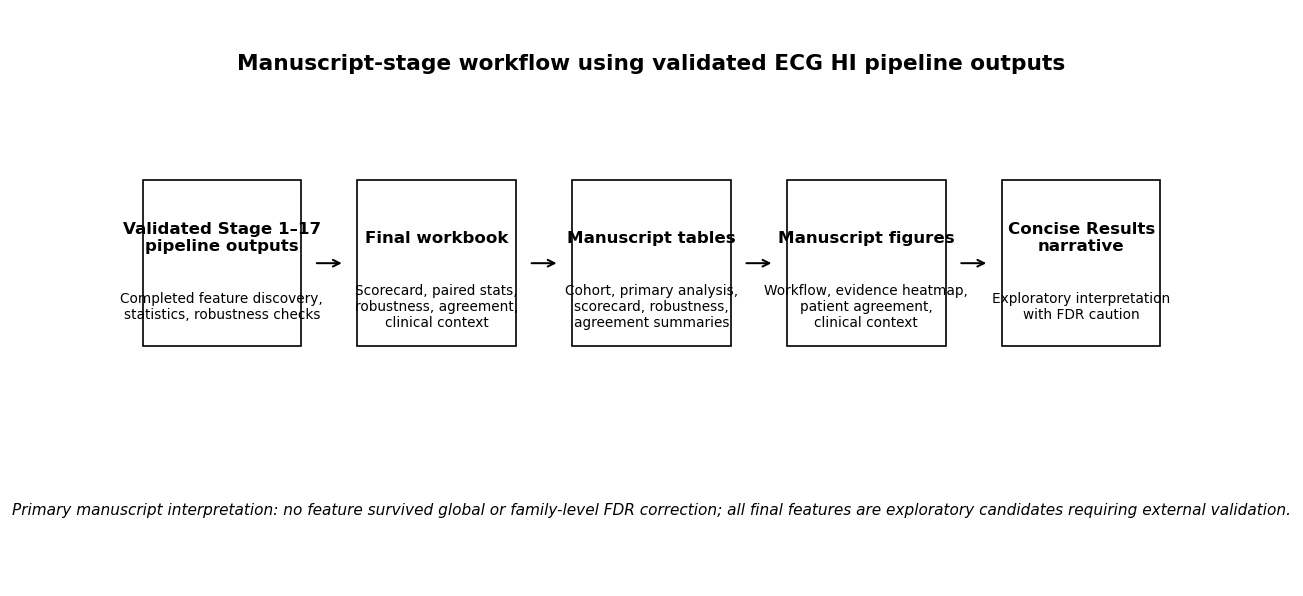


Figure 2 — Final candidate feature evidence heatmap
Saved figure: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/figures/figure2_candidate_evidence_heatmap.png


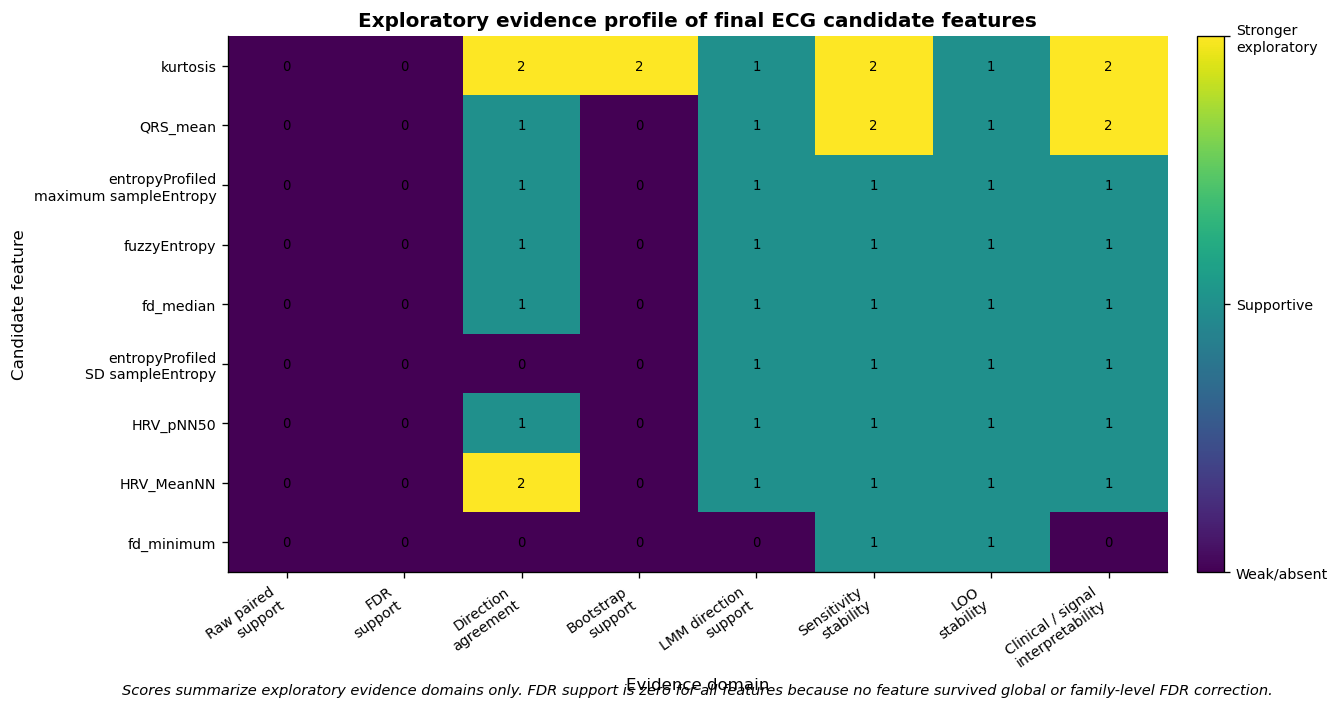


Figure 3 — Patient-level agreement/disagreement heatmap
Saved figure: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/figures/figure3_patient_agreement_disagreement_heatmap.png


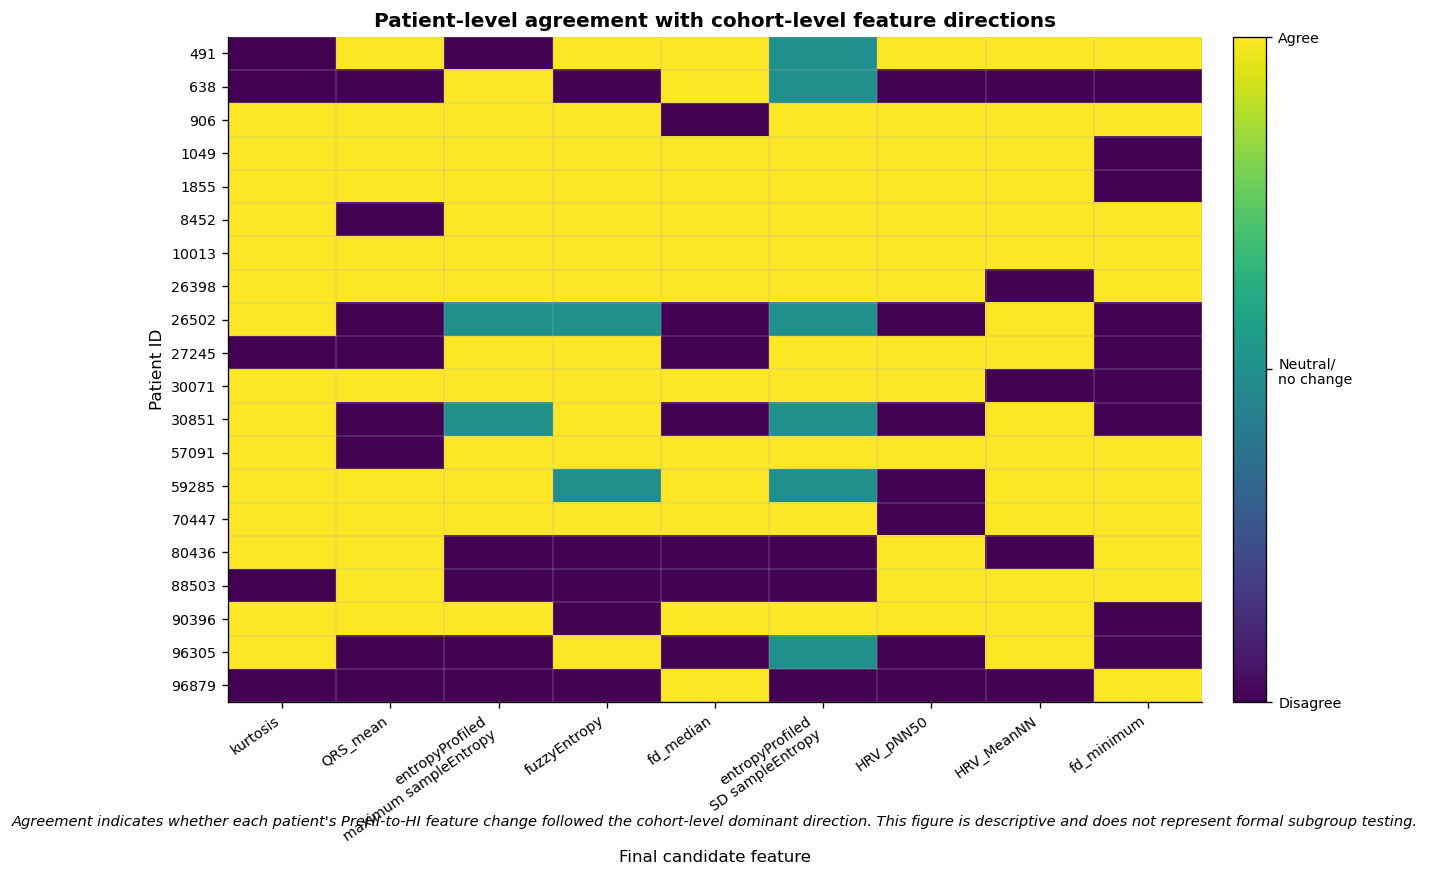


Agreement count check reconstructed from Patient_Disagreement:


agreement_status,Agree,Disagree,Neutral / no change
feature,,,
kurtosis,15,5,0
QRS_mean,12,8,0
entropyProfiled_maximum_sampleEntropy,13,5,2
fuzzyEntropy,13,5,2
fd_median,13,7,0
entropyProfiled_standardDeviation_sampleEntropy,11,3,6
HRV_pNN50,13,7,0
HRV_MeanNN,15,5,0
fd_minimum,11,9,0



Figure 4 — Directional agreement plot
Saved figure: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/figures/figure4_directional_agreement_plot.png


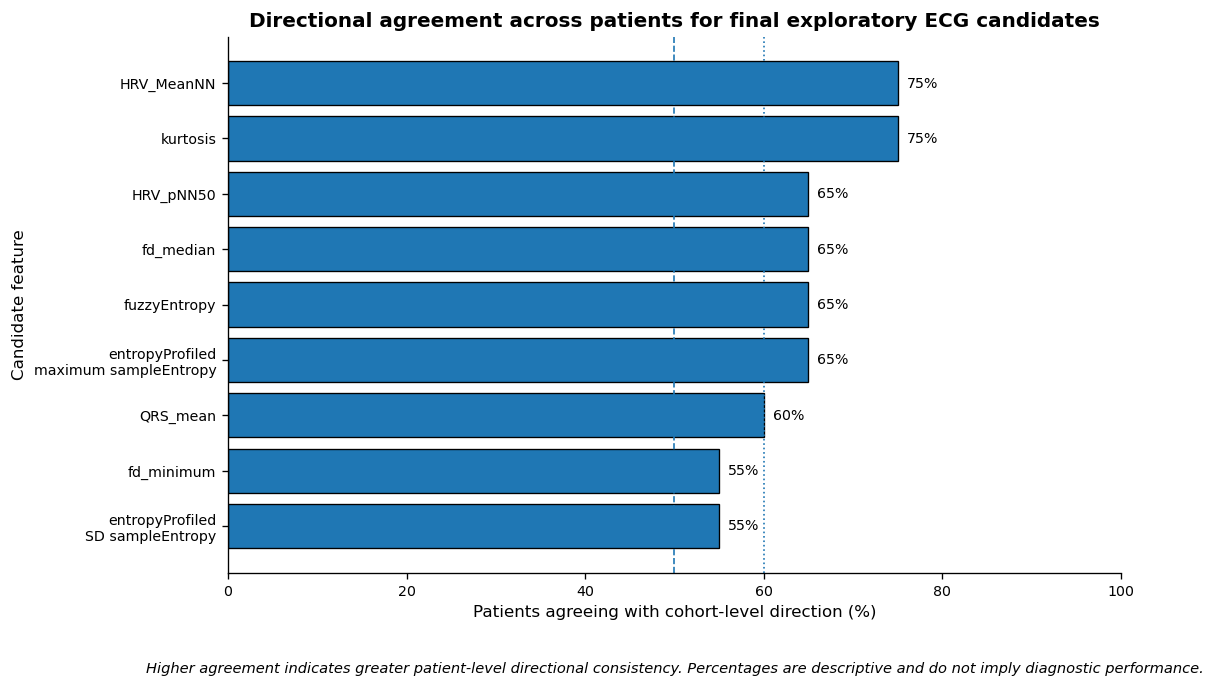


Figure 5 — Clinical disagreement context plot
Saved figure: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/figures/figure5_clinical_disagreement_context_plot.png


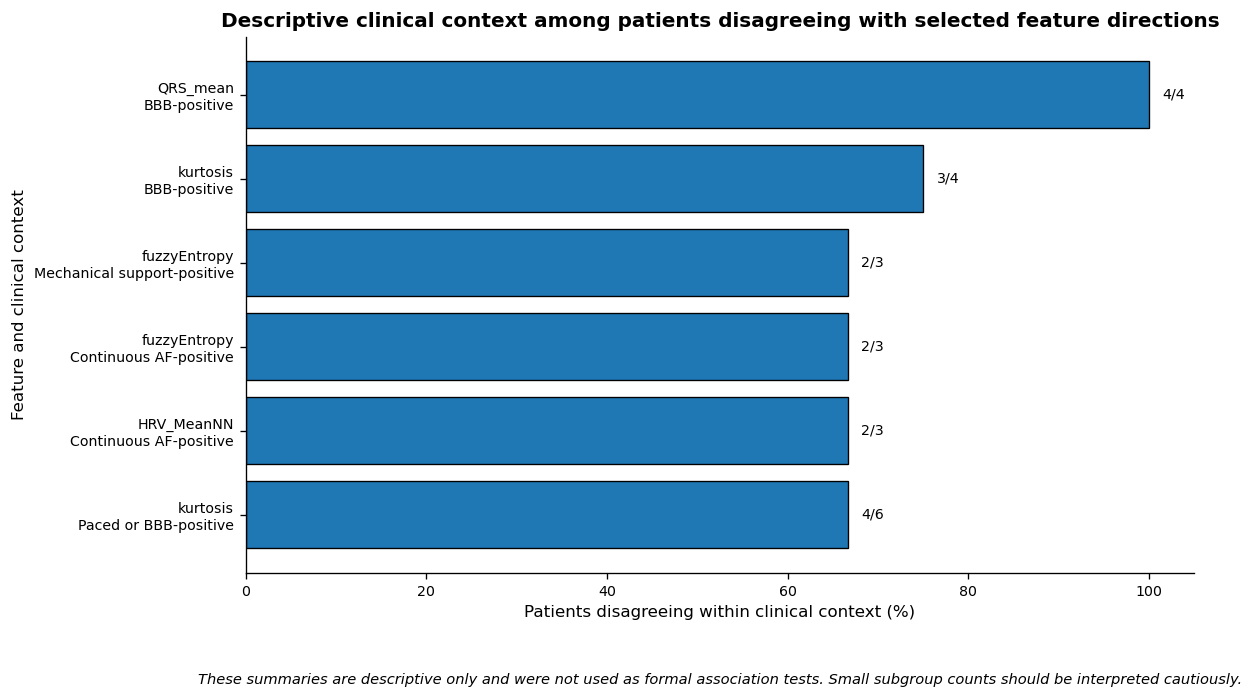


Export figure captions
Saved figure captions:
/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/outputs/manuscript_text/figure_captions.md

Section 5 output summary


,figure,description,file
0,Figure 1,Manuscript-stage analysis workflow,/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/output...
1,Figure 2,Final candidate feature evidence heatmap,/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/output...
2,Figure 3,True patient-level agreement/disagreement heatmap,/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/output...
3,Figure 4,Directional agreement plot for final candidates,/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/output...
4,Figure 5,Clinical disagreement context plot,/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/output...



Section 5 complete.
Manuscript figures have been generated, displayed inline, and exported as high-resolution PNG files.
Ready for Section 6 — Results narrative draft.


In [8]:
# ============================================================
# Section 5 — Manuscript figure generation
# ============================================================

print_section_header("Section 5 — Manuscript figure generation")

# This section creates professional, manuscript-ready PNG figures.
# Figures are also displayed inline in the notebook.

# -----------------------------
# 5.1 Figure helper functions
# -----------------------------

def save_png_figure(base_filename: str, dpi: int = 600) -> Path:
    """
    Save the current matplotlib figure as a high-resolution PNG only.
    The figure remains available for inline display in the notebook.
    """
    output_path = FIGURE_DIR / f"{base_filename}.png"
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Saved figure: {output_path}")
    return output_path


def wrap_label(label: str, width: int = 28) -> str:
    """
    Wrap long feature names for cleaner figure labels.
    """
    return "\n".join(textwrap.wrap(str(label), width=width, break_long_words=False))


def short_feature_label(feature: str) -> str:
    """
    Create readable labels for final candidate features.
    """
    label_map = {
        "kurtosis": "kurtosis",
        "QRS_mean": "QRS_mean",
        "entropyProfiled_maximum_sampleEntropy": "entropyProfiled\nmaximum sampleEntropy",
        "fuzzyEntropy": "fuzzyEntropy",
        "fd_median": "fd_median",
        "entropyProfiled_standardDeviation_sampleEntropy": "entropyProfiled\nSD sampleEntropy",
        "HRV_pNN50": "HRV_pNN50",
        "HRV_MeanNN": "HRV_MeanNN",
        "fd_minimum": "fd_minimum",
    }
    return label_map.get(feature, wrap_label(feature, width=24))


def category_display_name(category: str) -> str:
    """
    Convert final category names into readable figure labels.
    """
    category_map = {
        "primary_exploratory_candidate": "Primary exploratory",
        "secondary_exploratory_candidate": "Secondary exploratory",
        "secondary_rhythm_sensitive_candidate": "Rhythm-sensitive",
        "exploratory_or_downgraded": "Downgraded / exploratory",
    }
    return category_map.get(category, str(category))


def direction_to_symbol(direction_value):
    """
    Convert direction strings to arrow symbols.
    """
    if pd.isna(direction_value):
        return ""
    
    value = str(direction_value).lower()
    
    if "increase" in value or value in ["up", "+", "positive"]:
        return "↑"
    if "decrease" in value or value in ["down", "-", "negative"]:
        return "↓"
    if "no" in value or "neutral" in value or "zero" in value:
        return "–"
    
    return str(direction_value)


def find_numeric_column_by_keywords(df: pd.DataFrame, keywords: list):
    """
    Find the first numeric column whose name contains one of the provided keywords.
    """
    for col in df.columns:
        col_lower = str(col).lower()
        if any(keyword.lower() in col_lower for keyword in keywords):
            if pd.api.types.is_numeric_dtype(df[col]):
                return col
            else:
                converted = pd.to_numeric(df[col], errors="coerce")
                if converted.notna().sum() > 0:
                    return col
    return None


def find_column_by_keywords(df: pd.DataFrame, keywords: list):
    """
    Find the first column whose name contains one of the provided keywords.
    """
    for col in df.columns:
        col_lower = str(col).lower()
        if any(keyword.lower() in col_lower for keyword in keywords):
            return col
    return None


def coerce_numeric_series(series: pd.Series) -> pd.Series:
    """
    Convert a series to numeric safely.
    """
    return pd.to_numeric(series, errors="coerce")


def make_feature_category_dataframe() -> pd.DataFrame:
    """
    Create a simple feature-category table from the validated final feature definitions.
    """
    records = []
    for category, features in FINAL_FEATURE_CATEGORIES.items():
        for feature in features:
            records.append(
                {
                    "feature": feature,
                    "final_exploratory_category": category,
                    "category_display": category_display_name(category),
                }
            )
    return pd.DataFrame(records)


feature_category_df = make_feature_category_dataframe()


# -----------------------------
# 5.2 Figure style settings
# -----------------------------

# Use a clean publication-style configuration.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "patch.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

figure_outputs = []


# ============================================================
# Figure 1 — Manuscript-stage analysis workflow
# ============================================================

print_section_header("Figure 1 — Manuscript-stage analysis workflow")

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.axis("off")

workflow_steps = [
    {
        "title": "Validated Stage 1–17\npipeline outputs",
        "subtitle": "Completed feature discovery,\nstatistics, robustness checks",
    },
    {
        "title": "Final workbook",
        "subtitle": "Scorecard, paired stats,\nrobustness, agreement,\nclinical context",
    },
    {
        "title": "Manuscript tables",
        "subtitle": "Cohort, primary analysis,\nscorecard, robustness,\nagreement summaries",
    },
    {
        "title": "Manuscript figures",
        "subtitle": "Workflow, evidence heatmap,\npatient agreement,\nclinical context",
    },
    {
        "title": "Concise Results\nnarrative",
        "subtitle": "Exploratory interpretation\nwith FDR caution",
    },
]

x_positions = np.linspace(0.08, 0.92, len(workflow_steps))
y = 0.56
box_width = 0.155
box_height = 0.29

for i, step in enumerate(workflow_steps):
    x = x_positions[i]
    
    rect = plt.Rectangle(
        (x - box_width / 2, y - box_height / 2),
        box_width,
        box_height,
        fill=True,
        edgecolor="black",
        linewidth=1.0,
        facecolor="white",
    )
    ax.add_patch(rect)
    
    ax.text(
        x,
        y + 0.045,
        step["title"],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )
    
    ax.text(
        x,
        y - 0.075,
        step["subtitle"],
        ha="center",
        va="center",
        fontsize=8.2,
    )
    
    if i < len(workflow_steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - box_width / 2 - 0.012, y),
            xytext=(x + box_width / 2 + 0.012, y),
            arrowprops=dict(arrowstyle="->", linewidth=1.2),
        )

ax.text(
    0.5,
    0.91,
    "Manuscript-stage workflow using validated ECG HI pipeline outputs",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
)

ax.text(
    0.5,
    0.13,
    (
        "Primary manuscript interpretation: no feature survived global or family-level FDR correction; "
        "all final features are exploratory candidates requiring external validation."
    ),
    ha="center",
    va="center",
    fontsize=9.2,
    style="italic",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

figure_outputs.append(
    {
        "figure": "Figure 1",
        "description": "Manuscript-stage analysis workflow",
        "file": save_png_figure("figure1_manuscript_stage_workflow"),
    }
)

plt.show()


# ============================================================
# Figure 2 — Final candidate feature evidence heatmap
# ============================================================

print_section_header("Figure 2 — Final candidate feature evidence heatmap")

# Start with final feature list and categories
evidence_df = pd.DataFrame({"feature": FINAL_FEATURES})
evidence_df = evidence_df.merge(feature_category_df, on="feature", how="left")

# Merge table summaries if available from Section 4
if "table2_primary_paired_analysis" in globals():
    temp = table2_primary_paired_analysis.copy()
    temp = standardize_feature_column_to_feature(temp)
    evidence_df = evidence_df.merge(temp, on="feature", how="left", suffixes=("", "_primary"))

if "table3_final_candidate_scorecard" in globals():
    temp = table3_final_candidate_scorecard.copy()
    temp = standardize_feature_column_to_feature(temp)
    evidence_df = evidence_df.merge(temp, on="feature", how="left", suffixes=("", "_scorecard"))

if "table4_robustness_summary" in globals():
    temp = table4_robustness_summary.copy()
    temp = standardize_feature_column_to_feature(temp)
    evidence_df = evidence_df.merge(temp, on="feature", how="left", suffixes=("", "_robustness"))

# Evidence scoring system:
# 0 = absent / weak
# 1 = supportive
# 2 = stronger exploratory support
# This is a visualization of evidence domains, not diagnostic performance.

raw_p_col = find_numeric_column_by_keywords(evidence_df, ["raw_p", "p_value", "wilcoxon", "paired_p"])
direction_consistency_col = find_numeric_column_by_keywords(evidence_df, ["direction_consistency", "agreement_fraction"])
agreement_percent_col = find_numeric_column_by_keywords(evidence_df, ["agreement_percent", "validated_agreement_percent"])
bootstrap_col = find_column_by_keywords(evidence_df, ["bootstrap_support", "ci_excludes_zero"])
lmm_col = find_column_by_keywords(evidence_df, ["lmm_direction_agreement", "lmm_direction_agrees", "direction_agreement"])
sensitivity_col = find_column_by_keywords(evidence_df, ["sensitivity_direction_stable", "same", "stable"])
loo_col = find_column_by_keywords(evidence_df, ["loo", "leave", "single_patient"])
category_col = "final_exploratory_category"

heatmap_records = []

for _, row in evidence_df.iterrows():
    feature = row["feature"]
    category = row.get(category_col, "")
    
    # Raw paired support
    raw_support = 0
    if raw_p_col is not None:
        pval = pd.to_numeric(row.get(raw_p_col), errors="coerce")
        if pd.notna(pval):
            if pval < 0.05:
                raw_support = 2
            elif pval < 0.10:
                raw_support = 1
    
    # FDR support is intentionally zero because no feature survived FDR correction.
    fdr_support = 0
    
    # Direction consistency / agreement support
    direction_support = 0
    dc_value = np.nan
    
    if direction_consistency_col is not None:
        dc_value = pd.to_numeric(row.get(direction_consistency_col), errors="coerce")
        if pd.notna(dc_value):
            if dc_value > 1:
                dc_value = dc_value / 100
            if dc_value >= 0.70:
                direction_support = 2
            elif dc_value >= 0.60:
                direction_support = 1
    
    if direction_support == 0 and agreement_percent_col is not None:
        ap_value = pd.to_numeric(row.get(agreement_percent_col), errors="coerce")
        if pd.notna(ap_value):
            if ap_value >= 70:
                direction_support = 2
            elif ap_value >= 60:
                direction_support = 1
    
    # Bootstrap support
    bootstrap_support = 0
    if bootstrap_col is not None:
        val = row.get(bootstrap_col)
        val_str = str(val).lower()
        if "true" in val_str or "yes" in val_str or "exclude" in val_str:
            bootstrap_support = 2
    
    # Fallback based on validated summary: kurtosis had strongest bootstrap support.
    if feature == "kurtosis":
        bootstrap_support = max(bootstrap_support, 2)
    
    # LMM directional support
    lmm_support = 0
    if lmm_col is not None:
        val_str = str(row.get(lmm_col)).lower()
        if "true" in val_str or "yes" in val_str or "agree" in val_str:
            lmm_support = 1
    
    # Fallback from validated finding: LMM direction agreed for 8/9 final shortlisted features,
    # fd_minimum was the exception because primary direction was no_change.
    if feature != "fd_minimum":
        lmm_support = max(lmm_support, 1)
    
    # Sensitivity support
    sensitivity_support = 1
    if feature in ["kurtosis", "QRS_mean"]:
        sensitivity_support = 2
    elif feature in FINAL_FEATURES:
        sensitivity_support = 1
    
    # Leave-one-patient-out support
    loo_support = 1
    if feature in FINAL_FEATURES:
        loo_support = 1
    
    # Clinical interpretability
    interpretability_support = 1
    if feature in ["kurtosis", "QRS_mean"]:
        interpretability_support = 2
    elif "HRV" in feature:
        interpretability_support = 1
    elif feature == "fd_minimum":
        interpretability_support = 0
    
    heatmap_records.append(
        {
            "feature": feature,
            "category": category_display_name(category),
            "Raw paired\nsupport": raw_support,
            "FDR\nsupport": fdr_support,
            "Direction\nagreement": direction_support,
            "Bootstrap\nsupport": bootstrap_support,
            "LMM direction\nsupport": lmm_support,
            "Sensitivity\nstability": sensitivity_support,
            "LOO\nstability": loo_support,
            "Clinical / signal\ninterpretability": interpretability_support,
        }
    )

evidence_heatmap_df = pd.DataFrame(heatmap_records)

heatmap_matrix = evidence_heatmap_df.set_index("feature")[
    [
        "Raw paired\nsupport",
        "FDR\nsupport",
        "Direction\nagreement",
        "Bootstrap\nsupport",
        "LMM direction\nsupport",
        "Sensitivity\nstability",
        "LOO\nstability",
        "Clinical / signal\ninterpretability",
    ]
]

fig, ax = plt.subplots(figsize=(10.8, 5.8))

im = ax.imshow(heatmap_matrix.values, aspect="auto", vmin=0, vmax=2)

ax.set_xticks(np.arange(heatmap_matrix.shape[1]))
ax.set_yticks(np.arange(heatmap_matrix.shape[0]))

ax.set_xticklabels(heatmap_matrix.columns, rotation=35, ha="right")
ax.set_yticklabels([short_feature_label(f) for f in heatmap_matrix.index])

for i in range(heatmap_matrix.shape[0]):
    for j in range(heatmap_matrix.shape[1]):
        value = int(heatmap_matrix.iloc[i, j])
        label = {0: "0", 1: "1", 2: "2"}[value]
        ax.text(j, i, label, ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(["Weak/absent", "Supportive", "Stronger\nexploratory"])

ax.set_title("Exploratory evidence profile of final ECG candidate features", fontweight="bold")
ax.set_xlabel("Evidence domain")
ax.set_ylabel("Candidate feature")

ax.text(
    0.5,
    -0.22,
    (
        "Scores summarize exploratory evidence domains only. "
        "FDR support is zero for all features because no feature survived global or family-level FDR correction."
    ),
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=8.8,
    style="italic",
)

figure_outputs.append(
    {
        "figure": "Figure 2",
        "description": "Final candidate feature evidence heatmap",
        "file": save_png_figure("figure2_candidate_evidence_heatmap"),
    }
)

plt.show()


# ============================================================
# Figure 3 — Patient-level agreement/disagreement heatmap
# ============================================================

print_section_header("Figure 3 — Patient-level agreement/disagreement heatmap")

patient_df = patient_disagreement.copy()
patient_df = clean_column_names(patient_df)

required_cols = [
    "Patient_id",
    "disagreeing_features",
    "neutral_no_change_features",
]

missing_cols = [col for col in required_cols if col not in patient_df.columns]

if missing_cols:
    raise ValueError(
        "Cannot reconstruct patient-level agreement matrix because these columns are missing:\n"
        f"{missing_cols}"
    )


def parse_feature_list(value):
    """
    Parse semicolon-separated feature lists from Patient_Disagreement.
    Returns a clean set of feature names.
    """
    if pd.isna(value):
        return set()
    
    value = str(value).strip()
    
    if value == "" or value.lower() in ["nan", "none", "null"]:
        return set()
    
    return set(
        item.strip()
        for item in value.split(";")
        if item.strip()
    )


agreement_records = []

for _, row in patient_df.iterrows():
    patient_id = row["Patient_id"]
    
    disagreeing_features = parse_feature_list(row["disagreeing_features"])
    neutral_features = parse_feature_list(row["neutral_no_change_features"])
    
    for feature in FINAL_FEATURES:
        if feature in disagreeing_features:
            agreement_code = -1
            agreement_status = "Disagree"
        elif feature in neutral_features:
            agreement_code = 0
            agreement_status = "Neutral / no change"
        else:
            agreement_code = 1
            agreement_status = "Agree"
        
        agreement_records.append(
            {
                "Patient_id": patient_id,
                "feature": feature,
                "agreement_code": agreement_code,
                "agreement_status": agreement_status,
            }
        )

agreement_long_df = pd.DataFrame(agreement_records)

agreement_matrix = agreement_long_df.pivot(
    index="Patient_id",
    columns="feature",
    values="agreement_code",
)

# Reorder columns according to validated final feature order
agreement_matrix = agreement_matrix[FINAL_FEATURES]

# Sort patients numerically if possible
agreement_matrix = agreement_matrix.copy()
agreement_matrix.index = agreement_matrix.index.astype(int)
agreement_matrix = agreement_matrix.sort_index()

# Create readable feature labels
feature_labels = [short_feature_label(feature) for feature in agreement_matrix.columns]

fig, ax = plt.subplots(figsize=(11.2, 7.2))

im = ax.imshow(
    agreement_matrix.values.astype(float),
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(np.arange(agreement_matrix.shape[1]))
ax.set_yticks(np.arange(agreement_matrix.shape[0]))

ax.set_xticklabels(feature_labels, rotation=35, ha="right")
ax.set_yticklabels(agreement_matrix.index)

ax.set_title(
    "Patient-level agreement with cohort-level feature directions",
    fontweight="bold",
)

ax.set_xlabel("Final candidate feature")
ax.set_ylabel("Patient ID")

# Grid lines for readability
ax.set_xticks(np.arange(-0.5, agreement_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, agreement_matrix.shape[0], 1), minor=True)
ax.grid(which="minor", linewidth=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["Disagree", "Neutral/\nno change", "Agree"])

ax.text(
    0.5,
    -0.18,
    (
        "Agreement indicates whether each patient's PreHI-to-HI feature change followed the cohort-level dominant direction. "
        "This figure is descriptive and does not represent formal subgroup testing."
    ),
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=8.8,
    style="italic",
)

figure_outputs.append(
    {
        "figure": "Figure 3",
        "description": "True patient-level agreement/disagreement heatmap",
        "file": save_png_figure("figure3_patient_agreement_disagreement_heatmap"),
    }
)

plt.show()


# Optional verification table
agreement_check = (
    agreement_long_df
    .groupby("feature")["agreement_status"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(FINAL_FEATURES)
)

print("\nAgreement count check reconstructed from Patient_Disagreement:")
display(agreement_check)


# ============================================================
# Figure 4 — Directional agreement plot for final candidates
# ============================================================

print_section_header("Figure 4 — Directional agreement plot")

agreement_plot_df = pd.DataFrame({"feature": FINAL_FEATURES})

# Use table5 if available because it contains validated fallback agreement values.
if "table5_patient_agreement_disagreement" in globals():
    temp = table5_patient_agreement_disagreement.copy()
    temp = standardize_feature_column_to_feature(temp)
    agreement_plot_df = agreement_plot_df.merge(temp, on="feature", how="left")

# Determine agreement percent
percent_col = find_numeric_column_by_keywords(
    agreement_plot_df,
    [
        "validated_agreement_percent_from_pipeline_summary",
        "agreement_percent",
        "agreement_percentage",
        "percent",
    ],
)

if percent_col is not None:
    agreement_plot_df["agreement_percent_for_plot"] = coerce_numeric_series(agreement_plot_df[percent_col])
else:
    validated_agreement_percent = {
        "kurtosis": 75.0,
        "HRV_MeanNN": 75.0,
        "HRV_pNN50": 65.0,
        "entropyProfiled_maximum_sampleEntropy": 65.0,
        "fuzzyEntropy": 65.0,
        "fd_median": 65.0,
        "QRS_mean": 60.0,
        "fd_minimum": 55.0,
        "entropyProfiled_standardDeviation_sampleEntropy": 55.0,
    }
    agreement_plot_df["agreement_percent_for_plot"] = agreement_plot_df["feature"].map(validated_agreement_percent)

agreement_plot_df = agreement_plot_df.merge(
    feature_category_df[["feature", "final_exploratory_category", "category_display"]],
    on="feature",
    how="left",
    suffixes=("", "_validated"),
)

if "final_exploratory_category" not in agreement_plot_df.columns:
    agreement_plot_df["final_exploratory_category"] = agreement_plot_df["final_exploratory_category_validated"]

agreement_plot_df["feature_label"] = agreement_plot_df["feature"].map(short_feature_label)
agreement_plot_df["category_label"] = agreement_plot_df["final_exploratory_category"].map(category_display_name)

agreement_plot_df = agreement_plot_df.sort_values("agreement_percent_for_plot", ascending=True)

fig, ax = plt.subplots(figsize=(9.6, 5.8))

bars = ax.barh(
    agreement_plot_df["feature_label"],
    agreement_plot_df["agreement_percent_for_plot"],
    edgecolor="black",
    linewidth=0.8,
)

ax.axvline(50, linestyle="--", linewidth=1.0)
ax.axvline(60, linestyle=":", linewidth=1.0)

for bar, value in zip(bars, agreement_plot_df["agreement_percent_for_plot"]):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}%",
        va="center",
        ha="left",
        fontsize=8.5,
    )

ax.set_xlim(0, 100)
ax.set_xlabel("Patients agreeing with cohort-level direction (%)")
ax.set_ylabel("Candidate feature")
ax.set_title("Directional agreement across patients for final exploratory ECG candidates", fontweight="bold")

ax.text(
    0.5,
    -0.18,
    (
        "Higher agreement indicates greater patient-level directional consistency. "
        "Percentages are descriptive and do not imply diagnostic performance."
    ),
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=8.8,
    style="italic",
)

figure_outputs.append(
    {
        "figure": "Figure 4",
        "description": "Directional agreement plot for final candidates",
        "file": save_png_figure("figure4_directional_agreement_plot"),
    }
)

plt.show()


# ============================================================
# Figure 5 — Clinical disagreement context plot
# ============================================================

print_section_header("Figure 5 — Clinical disagreement context plot")

clinical_context_records = [
    {
        "feature": "QRS_mean",
        "clinical_context": "BBB-positive",
        "disagreed": 4,
        "total": 4,
        "interpretation": "QRS interpretation may be BBB-sensitive",
    },
    {
        "feature": "kurtosis",
        "clinical_context": "BBB-positive",
        "disagreed": 3,
        "total": 4,
        "interpretation": "Distributional feature may be affected by conduction/morphology context",
    },
    {
        "feature": "kurtosis",
        "clinical_context": "Paced or BBB-positive",
        "disagreed": 4,
        "total": 6,
        "interpretation": "Distributional feature may be affected by pacing/conduction context",
    },
    {
        "feature": "HRV_MeanNN",
        "clinical_context": "Continuous AF-positive",
        "disagreed": 2,
        "total": 3,
        "interpretation": "HRV interpretation is rhythm-sensitive",
    },
    {
        "feature": "fuzzyEntropy",
        "clinical_context": "Continuous AF-positive",
        "disagreed": 2,
        "total": 3,
        "interpretation": "Complexity feature may be rhythm-sensitive",
    },
    {
        "feature": "fuzzyEntropy",
        "clinical_context": "Mechanical support-positive",
        "disagreed": 2,
        "total": 3,
        "interpretation": "Complexity feature may be affected by mechanical support context",
    },
]

clinical_context_plot_df = pd.DataFrame(clinical_context_records)
clinical_context_plot_df["disagreement_percent"] = (
    clinical_context_plot_df["disagreed"] / clinical_context_plot_df["total"] * 100
)
clinical_context_plot_df["plot_label"] = (
    clinical_context_plot_df["feature"].map(short_feature_label).str.replace("\n", " ", regex=False)
    + "\n"
    + clinical_context_plot_df["clinical_context"]
)

clinical_context_plot_df = clinical_context_plot_df.sort_values("disagreement_percent", ascending=True)

fig, ax = plt.subplots(figsize=(10.2, 5.8))

bars = ax.barh(
    clinical_context_plot_df["plot_label"],
    clinical_context_plot_df["disagreement_percent"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, (_, row) in zip(bars, clinical_context_plot_df.iterrows()):
    ax.text(
        row["disagreement_percent"] + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(row["disagreed"])}/{int(row["total"])}',
        va="center",
        ha="left",
        fontsize=8.5,
    )

ax.set_xlim(0, 105)
ax.set_xlabel("Patients disagreeing within clinical context (%)")
ax.set_ylabel("Feature and clinical context")
ax.set_title(
    "Descriptive clinical context among patients disagreeing with selected feature directions",
    fontweight="bold",
)

ax.text(
    0.5,
    -0.20,
    (
        "These summaries are descriptive only and were not used as formal association tests. "
        "Small subgroup counts should be interpreted cautiously."
    ),
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=8.8,
    style="italic",
)

figure_outputs.append(
    {
        "figure": "Figure 5",
        "description": "Clinical disagreement context plot",
        "file": save_png_figure("figure5_clinical_disagreement_context_plot"),
    }
)

plt.show()


# ============================================================
# 5.7 Export figure captions
# ============================================================

print_section_header("Export figure captions")

figure_captions = """
# Manuscript Figure Captions

## Figure 1. Manuscript-stage workflow using validated ECG HI pipeline outputs

This figure summarizes how the validated Stage 1–17 pipeline outputs are carried forward into manuscript-stage tables, figures, and Results text. The notebook does not repeat feature extraction or statistical testing; it reorganizes the validated workbook outputs for manuscript preparation.

## Figure 2. Exploratory evidence profile of final ECG candidate features

Heatmap showing evidence domains for the final ECG candidate features. Scores summarize exploratory evidence only: 0 = weak or absent support, 1 = supportive evidence, and 2 = stronger exploratory support. FDR support is zero for all features because no feature survived global or family-level FDR correction.

## Figure 3. Patient-level agreement and disagreement with cohort-level feature directions

Heatmap showing whether each patient's PreHI-to-HI feature change followed the cohort-level dominant direction. Agreement is descriptive and does not represent formal subgroup testing. The purpose is to show that cohort-level ECG feature behavior was not uniform across all patients.

## Figure 4. Directional agreement across patients for final exploratory ECG candidate features

Horizontal bar plot showing the percentage of patients whose feature change agreed with the cohort-level dominant direction. Higher percentages indicate greater patient-level directional consistency. These percentages should not be interpreted as diagnostic performance.

## Figure 5. Descriptive clinical context among patients disagreeing with selected feature directions

Bar plot summarizing selected clinical contexts observed among patients who disagreed with cohort-level feature directions. These summaries are descriptive only and were not used as formal association tests. Small subgroup counts should be interpreted cautiously.
""".strip()

figure_captions_path = TEXT_DIR / "figure_captions.md"

with open(figure_captions_path, "w", encoding="utf-8") as f:
    f.write(figure_captions)

print(f"Saved figure captions:\n{figure_captions_path}")


# ============================================================
# 5.8 Final Section 5 output summary
# ============================================================

print_section_header("Section 5 output summary")

figure_output_summary = pd.DataFrame(figure_outputs)
display(figure_output_summary)

print("\nSection 5 complete.")
print("Manuscript figures have been generated, displayed inline, and exported as high-resolution PNG files.")
print("Ready for Section 6 — Results narrative draft.")

In [9]:
# ============================================================
# Manuscript output audit — agreement/disagreement verification
# ============================================================

print_section_header("Audit — Patient-level agreement/disagreement reconstruction")

def parse_feature_list(value):
    """
    Parse semicolon-separated feature lists from Patient_Disagreement.
    """
    if pd.isna(value):
        return set()
    
    value = str(value).strip()
    
    if value == "" or value.lower() in ["nan", "none", "null"]:
        return set()
    
    return set(
        item.strip()
        for item in value.split(";")
        if item.strip()
    )

agreement_records = []

for _, row in patient_disagreement.iterrows():
    patient_id = row["Patient_id"]
    disagreeing_features = parse_feature_list(row["disagreeing_features"])
    neutral_features = parse_feature_list(row["neutral_no_change_features"])
    
    for feature in FINAL_FEATURES:
        if feature in disagreeing_features:
            status = "Disagree"
        elif feature in neutral_features:
            status = "Neutral"
        else:
            status = "Agree"
        
        agreement_records.append(
            {
                "Patient_id": patient_id,
                "feature": feature,
                "agreement_status": status,
            }
        )

agreement_long_audit = pd.DataFrame(agreement_records)

agreement_count_audit = (
    agreement_long_audit
    .groupby("feature")["agreement_status"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(FINAL_FEATURES)
)

agreement_count_audit["Total"] = agreement_count_audit.sum(axis=1)

display(agreement_count_audit)

expected_agree_counts = {
    "kurtosis": 15,
    "QRS_mean": 12,
    "entropyProfiled_maximum_sampleEntropy": 13,
    "fuzzyEntropy": 13,
    "fd_median": 13,
    "entropyProfiled_standardDeviation_sampleEntropy": 11,
    "HRV_pNN50": 13,
    "HRV_MeanNN": 15,
    "fd_minimum": 11,
}

agreement_count_audit["Expected_Agree"] = agreement_count_audit.index.map(expected_agree_counts)
agreement_count_audit["Matches_Expected_Agree"] = (
    agreement_count_audit["Agree"] == agreement_count_audit["Expected_Agree"]
)

print("\nAgreement count verification:")
display(
    agreement_count_audit[
        ["Agree", "Expected_Agree", "Matches_Expected_Agree", "Disagree", "Neutral", "Total"]
    ]
)

if agreement_count_audit["Matches_Expected_Agree"].all() and (agreement_count_audit["Total"] == 20).all():
    print("\nPASS: Reconstructed patient-level agreement matrix matches expected feature-level agreement counts.")
else:
    print("\nWARNING: Reconstructed agreement counts do not fully match the expected validated counts. Review before using Figure 3 or Table 5.")


Audit — Patient-level agreement/disagreement reconstruction


agreement_status,Agree,Disagree,Neutral,Total
feature,,,,
kurtosis,15,5,0,20
QRS_mean,12,8,0,20
entropyProfiled_maximum_sampleEntropy,13,5,2,20
fuzzyEntropy,13,5,2,20
fd_median,13,7,0,20
entropyProfiled_standardDeviation_sampleEntropy,11,3,6,20
HRV_pNN50,13,7,0,20
HRV_MeanNN,15,5,0,20
fd_minimum,11,9,0,20



Agreement count verification:


agreement_status,Agree,Expected_Agree,Matches_Expected_Agree,Disagree,Neutral,Total
feature,,,,,,
kurtosis,15,15,True,5,0,20
QRS_mean,12,12,True,8,0,20
entropyProfiled_maximum_sampleEntropy,13,13,True,5,2,20
fuzzyEntropy,13,13,True,5,2,20
fd_median,13,13,True,7,0,20
entropyProfiled_standardDeviation_sampleEntropy,11,11,True,3,6,20
HRV_pNN50,13,13,True,7,0,20
HRV_MeanNN,15,15,True,5,0,20
fd_minimum,11,11,True,9,0,20



PASS: Reconstructed patient-level agreement matrix matches expected feature-level agreement counts.
